In [1]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from typing import Dict, List, Optional
import os
from dataclasses import dataclass, field
from typing import List, Tuple
import torch
import torch.nn as nn
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
from typing import Dict, Tuple, Optional
import os
import json
from datetime import datetime
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
from tqdm import tqdm


In [2]:
import ssl
import certifi
import urllib.request

ssl_context = ssl.create_default_context(cafile=certifi.where())

ssl_context = ssl.create_default_context(cafile=certifi.where())
opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=ssl_context))
urllib.request.install_opener(opener)

### helper functions

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    if torch.mps.is_available():
        torch.mps.manual_seed(seed)

def get_device():
    """Uygun device'ı seç"""
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"🖥️  GPU kullanılıyor: {torch.cuda.get_device_name(0)}")
    elif torch.backends.mps.is_available():
        device = torch.device('mps')
        print("🖥️  Apple MPS kullanılıyor")
    else:
        device = torch.device('cpu')
        print("🖥️  CPU kullanılıyor")

    return device

def plot_training_history(
    history: Dict[str, List],
    save_path: Optional[str] = None,
    figsize: tuple = (14, 5)
):
    """
    Eğitim geçmişini görselleştir
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    epochs = range(1, len(history['train_loss']) + 1)

    # Loss grafiği
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy grafiği
    axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, [a*100 for a in history['val_acc']], 'r-', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training & Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Learning rate grafiği
    axes[2].plot(epochs, history['lr'], 'g-', linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_title('Learning Rate Schedule')
    axes[2].set_yscale('log')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Eğitim grafiği kaydedildi: {save_path}")

    plt.show()


def count_parameters(model: torch.nn.Module) -> Dict[str, int]:
    """Model parametre sayısını hesapla"""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        'total': total,
        'trainable': trainable,
        'frozen': total - trainable
    }


def print_model_summary(model: torch.nn.Module, model_name: str = "Model"):
    """Model özeti yazdır"""
    params = count_parameters(model)

    print(f"\n{'='*50}")
    print(f"📋 {model_name} Özeti")
    print(f"{'='*50}")
    print(f"Toplam Parametre:    {params['total']:,}")
    print(f"Eğitilebilir:        {params['trainable']:,}")
    print(f"Dondurulmuş:         {params['frozen']:,}")
    print(f"{'='*50}\n")


### config

In [4]:
@dataclass
class Config:
    # Veri seti ayarları
    data_dir: str = "./data/images_original"
    image_size: Tuple[int, int] = (224, 224)

    # GTZAN sınıfları
    classes: List[str] = field(default_factory=lambda: [
        'blues', 'classical', 'country', 'disco', 'hiphop',
        'jazz', 'metal', 'pop', 'reggae', 'rock'
    ])
    num_classes: int = 10

    # Eğitim ayarları
    batch_size: int = 32
    num_epochs: int = 100
    learning_rate: float = 3e-4
    weight_decay: float = 1e-3

    # Train/Val/Test split oranları
    train_ratio: float = 0.7
    val_ratio: float = 0.15
    test_ratio: float = 0.15

    # Model ayarları
    model_name: str = "cnn"  # "cnn", "resnet18", "efficientnet"
    pretrained: bool = True
    dropout_rate: float = 0.3

    device: torch.device = field(default_factory=get_device)
    num_workers: int = 0
    seed: int = 42
    save_dir: str = "./checkpoints"

    # Early stopping
    patience: int = 15
    min_delta: float = 0.001

    compare_all = False


### dataset & dataloader

In [5]:
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
from typing import Tuple, Dict, List, Optional
import numpy as np


class GTZANImageDataset(Dataset):

    def __init__(
        self,
        data_dir: str,
        transform: Optional[transforms.Compose] = None,
        classes: Optional[List[str]] = None
    ):
        self.data_dir = data_dir
        self.transform = transform
        self.classes = classes or [
            'blues', 'classical', 'country', 'disco', 'hiphop',
            'jazz', 'metal', 'pop', 'reggae', 'rock'
        ]
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.idx_to_class = {idx: cls for cls, idx in self.class_to_idx.items()}

        # Tüm görüntü yollarını ve etiketlerini topla
        self.samples = self._load_samples()

    def _load_samples(self) -> List[Tuple[str, int]]:
        """Tüm görüntü yollarını ve etiketlerini yükle"""
        samples = []

        for class_name in self.classes:
            class_dir = os.path.join(self.data_dir, class_name)

            if not os.path.exists(class_dir):
                print(f"⚠️ Uyarı: {class_dir} bulunamadı!")
                continue

            for img_name in os.listdir(class_dir):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_dir, img_name)
                    label = self.class_to_idx[class_name]
                    samples.append((img_path, label))

        print(f"📊 Toplam {len(samples)} görüntü yüklendi.")
        return samples

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        img_path, label = self.samples[idx]

        # Görüntüyü yükle
        image = Image.open(img_path).convert('RGB')

        # Transform uygula
        if self.transform:
            image = self.transform(image)

        return image, label


def get_transforms(config: Config, mode: str = 'train') -> transforms.Compose:
    """
    Veri augmentasyonu ve preprocessing transform'ları

    Args:
        config: Konfigürasyon objesi
        mode: 'train', 'val' veya 'test'
    """
    if mode == 'train':
        return transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.RandomHorizontalFlip(p=0.3),
            transforms.RandomRotation(degrees=5),
            transforms.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.1,
                hue=0.05
            ),
            transforms.RandomAffine(
                degrees=0,
                translate=(0.05, 0.05),
                scale=(0.9, 1.1)
            ),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1,0.2)),  # Blur eklendi
            transforms.ToTensor(),
            transforms.Normalize(
                 mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225]
            ) ,
            transforms.RandomErasing(p=0.1, scale=(0.02, 0.33))
        ])
    else:
        # Validation ve Test için augmentasyon yok
        return transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])


def create_dataloaders(config: Config) -> Dict[str, DataLoader]:
    """
    Train, validation ve test DataLoader'larını oluştur

    Returns:
        Dict containing 'train', 'val', 'test' DataLoaders
    """
    # Önce transform'suz full dataset oluştur (split için)
    full_dataset = GTZANImageDataset(
        data_dir=config.data_dir,
        transform=None,
        classes=config.classes
    )

    # Dataset boyutlarını hesapla
    total_size = len(full_dataset)
    train_size = int(total_size * config.train_ratio)
    val_size = int(total_size * config.val_ratio)
    test_size = total_size - train_size - val_size

    print(f"\n📊 Dataset Split:")
    print(f"   Train: {train_size} ({config.train_ratio*100:.0f}%)")
    print(f"   Val:   {val_size} ({config.val_ratio*100:.0f}%)")
    print(f"   Test:  {test_size} ({config.test_ratio*100:.0f}%)")

    # Random split
    torch.manual_seed(config.seed)
    train_subset, val_subset, test_subset = random_split(
        full_dataset,
        [train_size, val_size, test_size]
    )

    # Her split için ayrı dataset (farklı transform'lar için)
    train_dataset = SubsetWithTransform(
        train_subset,
        get_transforms(config, 'train')
    )
    val_dataset = SubsetWithTransform(
        val_subset,
        get_transforms(config, 'val')
    )
    test_dataset = SubsetWithTransform(
        test_subset,
        get_transforms(config, 'test')
    )

    # DataLoader'ları oluştur
    dataloaders = {
        'train': DataLoader(
            train_dataset,
            batch_size=config.batch_size,
            shuffle=True,
            num_workers=config.num_workers,
            pin_memory=False,
            drop_last=True
        ),
        'val': DataLoader(
            val_dataset,
            batch_size=config.batch_size,
            shuffle=False,
            num_workers=config.num_workers,
            pin_memory=False
        ),
        'test': DataLoader(
            test_dataset,
            batch_size=config.batch_size,
            shuffle=False,
            num_workers=config.num_workers,
            pin_memory=False
        )
    }

    return dataloaders


class SubsetWithTransform(Dataset):
    """Subset'e transform eklemeye izin veren wrapper"""

    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img_path, label = self.subset.dataset.samples[self.subset.indices[idx]]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label


### cnn model

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock(nn.Module):
    """Konvolüsyon bloğu: Conv -> BatchNorm -> ReLU -> MaxPool"""

    def __init__(self, in_channels: int, out_channels: int, pool: bool = True):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(2, 2) if pool else nn.Identity()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        return x


class SimpleCNN(nn.Module):
    """
    GTZAN görüntü sınıflandırması için basit CNN

    Mimari:
        Input (3, 224, 224)
            ↓
        ConvBlock(3→32)   → (32, 112, 112)
        ConvBlock(32→64)  → (64, 56, 56)
        ConvBlock(64→128) → (128, 28, 28)
        ConvBlock(128→256)→ (256, 14, 14)
        ConvBlock(256→512)→ (512, 7, 7)
            ↓
        AdaptiveAvgPool   → (512, 1, 1)
            ↓
        FC(512→256) → FC(256→num_classes)
    """

    def __init__(self, num_classes: int = 10, dropout_rate: float = 0.5):
        super().__init__()

        self.features = nn.Sequential(
            ConvBlock(3, 32),      # 224 → 112
            ConvBlock(32, 64),     # 112 → 56
            ConvBlock(64, 128),    # 56 → 28
            ConvBlock(128, 256),   # 28 → 14
            ConvBlock(256, 512),   # 14 → 7
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

        # Ağırlık başlatma
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

    def get_features(self, x):
        """Feature extraction (transfer learning için)"""
        x = self.features(x)
        x = self.avgpool(x)
        return x.flatten(1)


In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

In [8]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False)
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        avg_out = self.fc(self.avg_pool(x).view(b, c))
        max_out = self.fc(self.max_pool(x).view(b, c))
        attention = torch.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * attention

In [9]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes: int = 10, dropout_rate: float = 0.5):
        super().__init__()

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        # Residual blocks with attention
        self.layer1 = self._make_layer(32, 64, 2, stride=2)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)

        # Attention
        self.attention = ChannelAttention(512)

        # Classifier
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(256, num_classes)
        )

        self._initialize_weights()

    def _make_layer(self, in_ch, out_ch, num_blocks, stride):
        layers = [ResidualBlock(in_ch, out_ch, stride)]
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_ch, out_ch, 1))
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.attention(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        x = self.classifier(x)
        return x

In [10]:
class EnhancedCNN(nn.Module):
    """Daha güçlü CNN mimarisi"""

    def __init__(self, num_classes: int = 10, dropout_rate: float = 0.5):
        super().__init__()

        # Stem with larger receptive field
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        # Residual blocks with SE attention
        self.layer1 = self._make_layer(64, 64, 2, stride=1)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)

        # Global pooling + classifier
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.maxpool = nn.AdaptiveMaxPool2d(1)  # Dual pooling

        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(512 * 2, 512),  # Dual pooling için *2
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(512, num_classes)
        )

        self._initialize_weights()

    def _make_layer(self, in_ch, out_ch, num_blocks, stride):
        layers = [SEResidualBlock(in_ch, out_ch, stride)]
        for _ in range(1, num_blocks):
            layers.append(SEResidualBlock(out_ch, out_ch, 1))
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Dual pooling (avg + max concatenation)
        avg_out = self.avgpool(x).flatten(1)
        max_out = self.maxpool(x).flatten(1)
        x = torch.cat([avg_out, max_out], dim=1)

        return self.classifier(x)


class SEResidualBlock(nn.Module):
    """Squeeze-and-Excitation Residual Block"""

    def __init__(self, in_channels, out_channels, stride=1, reduction=16):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # SE block
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(out_channels, out_channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(out_channels // reduction, out_channels, bias=False),
            nn.Sigmoid()
        )

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # SE attention
        se_weight = self.se(out).view(out.size(0), out.size(1), 1, 1)
        out = out * se_weight

        out += self.shortcut(x)
        return F.relu(out)

### efficientnet model

In [11]:
"""
EfficientNet Model for GTZAN Classification
"""
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights, EfficientNet_B3_Weights


class EfficientNetClassifier(nn.Module):
    """
    EfficientNet tabanlı sınıflandırıcı

    Özellikler:
        - EfficientNet-B0 veya B3 backbone
        - ImageNet pretrained ağırlıklar
        - Özelleştirilmiş classifier head
        - Squeeze-and-Excitation blokları
    """

    def __init__(
        self,
        num_classes: int = 10,
        pretrained: bool = True,
        dropout_rate: float = 0.5,
        variant: str = 'b0',  # 'b0' veya 'b3'
        freeze_backbone: bool = False
    ):
        super().__init__()

        self.variant = variant

        # EfficientNet variant seçimi
        if variant == 'b0':
            if pretrained:
                weights = EfficientNet_B0_Weights.IMAGENET1K_V1
                self.backbone = models.efficientnet_b0(weights=weights)
                print("✅ EfficientNet-B0 ImageNet ağırlıkları yüklendi")
            else:
                self.backbone = models.efficientnet_b0(weights=None)
            num_features = 1280

        elif variant == 'b3':
            if pretrained:
                weights = EfficientNet_B3_Weights.IMAGENET1K_V1
                self.backbone = models.efficientnet_b3(weights=weights)
                print("✅ EfficientNet-B3 ImageNet ağırlıkları yüklendi")
            else:
                self.backbone = models.efficientnet_b3(weights=None)
            num_features = 1536
        else:
            raise ValueError(f"Bilinmeyen variant: {variant}")

        # Orijinal classifier'ı kaldır
        self.backbone.classifier = nn.Identity()

        # Yeni classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate, inplace=True),
            nn.Linear(num_features, 512),
            nn.SiLU(inplace=True),  # EfficientNet SiLU kullanıyor
            nn.Dropout(dropout_rate / 2),
            nn.Linear(512, 256),
            nn.SiLU(inplace=True),
            nn.Linear(256, num_classes)
        )

        if freeze_backbone:
            self.freeze_backbone()

    def freeze_backbone(self):
        """Backbone'u dondur"""
        for param in self.backbone.parameters():
            param.requires_grad = False
        print("🔒 EfficientNet backbone donduruldu")

    def unfreeze_backbone(self, num_blocks: int = None):
        """
        Backbone bloklarını çöz

        Args:
            num_blocks: Çözülecek son blok sayısı
        """
        if num_blocks is None:
            for param in self.backbone.parameters():
                param.requires_grad = True
            print("🔓 Tüm backbone çözüldü")
        else:
            # EfficientNet'in features bölümünün son N bloğunu çöz
            features = self.backbone.features
            total_blocks = len(features)

            for i, block in enumerate(features):
                if i >= total_blocks - num_blocks:
                    for param in block.parameters():
                        param.requires_grad = True
            print(f"🔓 Son {num_blocks} blok çözüldü")

    def forward(self, x):
        features = self.backbone(x)
        output = self.classifier(features)
        return output

    def get_features(self, x):
        """Feature extraction"""
        return self.backbone(x)

    def get_trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def get_total_params(self):
        return sum(p.numel() for p in self.parameters())


### resnet18 model

In [12]:
"""
ResNet18 Model for GTZAN Classification
"""
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import ResNet18_Weights


class ResNetClassifier(nn.Module):
    """
    ResNet18 tabanlı sınıflandırıcı

    Özellikler:
        - ImageNet pretrained ağırlıklar
        - Özelleştirilmiş classifier head
        - Feature extraction modu
        - Gradual unfreezing desteği
    """

    def __init__(
        self,
        num_classes: int = 10,
        pretrained: bool = True,
        dropout_rate: float = 0.5,
        freeze_backbone: bool = False
    ):
        super().__init__()

        # Pretrained ResNet18 yükle
        if pretrained:
            weights = ResNet18_Weights.IMAGENET1K_V1
            self.backbone = models.resnet18(weights=weights)
            print("✅ ResNet18 ImageNet ağırlıkları yüklendi")
        else:
            self.backbone = models.resnet18(weights=None)
            print("⚠️ ResNet18 random ağırlıklarla başlatıldı")

        # Backbone'un feature boyutu
        num_features = self.backbone.fc.in_features  # 512

        # Orijinal FC katmanını kaldır
        self.backbone.fc = nn.Identity()

        # Yeni classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(256, num_classes)
        )

        # Backbone'u dondur (opsiyonel)
        if freeze_backbone:
            self.freeze_backbone()

    def freeze_backbone(self):
        """Backbone katmanlarını dondur"""
        for param in self.backbone.parameters():
            param.requires_grad = False
        print("🔒 Backbone donduruldu")

    def unfreeze_backbone(self, num_layers: int = None):
        """
        Backbone katmanlarını çöz

        Args:
            num_layers: Çözülecek son katman sayısı (None = hepsi)
        """
        if num_layers is None:
            for param in self.backbone.parameters():
                param.requires_grad = True
            print("🔓 Tüm backbone çözüldü")
        else:
            # Sadece son N katmanı çöz
            layers = list(self.backbone.children())
            for layer in layers[-num_layers:]:
                for param in layer.parameters():
                    param.requires_grad = True
            print(f"🔓 Son {num_layers} katman çözüldü")

    def forward(self, x):
        features = self.backbone(x)
        output = self.classifier(features)
        return output

    def get_features(self, x):
        """Feature extraction"""
        return self.backbone(x)

    def get_trainable_params(self):
        """Eğitilebilir parametre sayısını döndür"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def get_total_params(self):
        """Toplam parametre sayısını döndür"""
        return sum(p.numel() for p in self.parameters())

### training

In [13]:
class EarlyStopping:
    """Early stopping callback"""

    def __init__(self, patience: int = 10, min_delta: float = 0.001, mode: str = 'min'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
        elif self._is_improvement(score):
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

    def _is_improvement(self, score):
        if self.mode == 'min':
            return score < self.best_score - self.min_delta
        return score > self.best_score + self.min_delta


class Trainer:
    """
    Model eğitimi için ana sınıf
    """

    def __init__(
        self,
        model: nn.Module,
        config: Config,
        dataloaders: Dict[str, DataLoader]
    ):
        self.model = model.to(config.device)
        self.config = config
        self.dataloaders = dataloaders
        self.device = config.device

        # Loss fonksiyonu
        self.criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

        # Optimizer
        self.optimizer = AdamW(
            self.model.parameters(),
            lr=config.learning_rate,
            weight_decay=config.weight_decay
        )

        # Learning rate scheduler
        self.scheduler = CosineAnnealingLR(
            self.optimizer,
            T_max=config.num_epochs,
            eta_min=1e-6
        )

        # Early stopping
        self.early_stopping = EarlyStopping(
            patience=config.patience,
            min_delta=config.min_delta,
            mode='min'
        )

        # Eğitim geçmişi
        self.history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'lr': []
        }

        # En iyi model takibi
        self.best_val_loss = float('inf')
        self.best_val_acc = 0.0
        self.best_epoch = 0

    def train_epoch(self) -> Tuple[float, float]:
        """Bir epoch eğitim"""
        self.model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(self.dataloaders['train'], desc='Training', leave=False)

        for images, labels in pbar:
            images = images.to(self.device)
            labels = labels.to(self.device)

            # Forward pass
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)

            # Backward pass
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

            self.optimizer.step()

            # Metrikler
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Progress bar güncelle
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        return epoch_loss, epoch_acc

    def validate(self) -> Tuple[float, float]:
        """Validation"""
        self.model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in tqdm(self.dataloaders['val'], desc='Validation', leave=False):
                images = images.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        return epoch_loss, epoch_acc

    def train(self) -> Dict:
        """
        Tam eğitim döngüsü

        Returns:
            Eğitim geçmişi
        """
        print(f"\n{'='*60}")
        print(f"🚀 Eğitim Başlıyor")
        print(f"   Model: {self.config.model_name}")
        print(f"   Device: {self.device}")
        print(f"   Epochs: {self.config.num_epochs}")
        print(f"{'='*60}\n")

        for epoch in range(self.config.num_epochs):
            print(f"\nEpoch {epoch+1}/{self.config.num_epochs}")
            print("-" * 40)

            # Training
            train_loss, train_acc = self.train_epoch()

            # Validation
            val_loss, val_acc = self.validate()

            # Learning rate
            current_lr = self.optimizer.param_groups[0]['lr']
            self.scheduler.step()

            # Geçmişi kaydet
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['lr'].append(current_lr)

            # Sonuçları yazdır
            print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
            print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")
            print(f"LR: {current_lr:.6f}")

            # En iyi model kontrolü
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.best_val_acc = val_acc
                self.best_epoch = epoch + 1
                self.save_checkpoint('best_model.pth')
                print(f"✅ En iyi model kaydedildi!")

            # Early stopping kontrolü
            if self.early_stopping(val_loss):
                print(f"\n⚠️ Early stopping! Epoch {epoch+1}")
                break

        # Son model kaydet
        self.save_checkpoint('last_model.pth')

        print(f"\n{'='*60}")
        print(f"🏁 Eğitim Tamamlandı!")
        print(f"   En İyi Val Loss: {self.best_val_loss:.4f} (Epoch {self.best_epoch})")
        print(f"   En İyi Val Acc:  {self.best_val_acc*100:.2f}%")
        print(f"{'='*60}")

        return self.history

    def save_checkpoint(self, filename: str):
        """Model checkpoint kaydet"""
        os.makedirs(self.config.save_dir, exist_ok=True)

        checkpoint = {
            'epoch': len(self.history['train_loss']),
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'best_val_loss': self.best_val_loss,
            'best_val_acc': self.best_val_acc,
            'history': self.history,
            'config': {
                'model_name': self.config.model_name,
                'num_classes': self.config.num_classes,
                'image_size': self.config.image_size
            }
        }

        path = os.path.join(self.config.save_dir, filename)
        torch.save(checkpoint, path)

    def load_checkpoint(self, filename: str):
        """Model checkpoint yükle"""
        path = os.path.join(self.config.save_dir, filename)
        checkpoint = torch.load(path, map_location=self.device)

        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        self.best_val_loss = checkpoint['best_val_loss']
        self.best_val_acc = checkpoint['best_val_acc']
        self.history = checkpoint['history']

        print(f"✅ Checkpoint yüklendi: {filename}")




In [14]:
def train_model(
    model: nn.Module,
    dataloaders: Dict[str, DataLoader],
    config: Config
) -> Tuple[nn.Module, Dict]:
    """
    Convenience fonksiyonu - hızlı eğitim başlatma

    Returns:
        (trained_model, history)
    """
    trainer = Trainer(model, config, dataloaders)
    history = trainer.train()

    # En iyi modeli yükle
    trainer.load_checkpoint('best_model.pth')

    return trainer.model, history


### evaluation

In [15]:
class Evaluator:
    """
    Model değerlendirme sınıfı
    """

    def __init__(
        self,
        model: nn.Module,
        dataloader: DataLoader,
        config: Config,
        class_names: Optional[List[str]] = None
    ):
        self.model = model.to(config.device)
        self.dataloader = dataloader
        self.device = config.device
        self.class_names = class_names or config.classes

        # Sonuçları sakla
        self.all_preds = []
        self.all_labels = []
        self.all_probs = []

    def evaluate(self) -> Dict:
        """
        Tam değerlendirme yap

        Returns:
            Değerlendirme metrikleri dictionary'si
        """
        self.model.eval()

        self.all_preds = []
        self.all_labels = []
        self.all_probs = []

        print("\n🔍 Model değerlendiriliyor...")

        with torch.no_grad():
            for images, labels in tqdm(self.dataloader, desc='Evaluating'):
                images = images.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(images)
                probs = torch.softmax(outputs, dim=1)
                _, preds = outputs.max(1)

                self.all_preds.extend(preds.detach().cpu().numpy())
                self.all_labels.extend(labels.cpu().numpy())
                self.all_probs.extend(probs.detach().cpu().numpy())

        self.all_preds = np.array(self.all_preds)
        self.all_labels = np.array(self.all_labels)
        self.all_probs = np.array(self.all_probs)

        # Metrikleri hesapla
        metrics = self._calculate_metrics()

        return metrics

    def _calculate_metrics(self) -> Dict:
        """Tüm metrikleri hesapla"""

        # Temel metrikler
        accuracy = accuracy_score(self.all_labels, self.all_preds)

        precision, recall, f1, support = precision_recall_fscore_support(
            self.all_labels,
            self.all_preds,
            average='weighted',
            zero_division=0
        )

        # Sınıf bazlı metrikler
        precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
            self.all_labels,
            self.all_preds,
            average=None,
            zero_division=0
        )

        # Confusion matrix
        cm = confusion_matrix(self.all_labels, self.all_preds)

        metrics = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'confusion_matrix': cm,
            'per_class': {
                'precision': precision_per_class,
                'recall': recall_per_class,
                'f1_score': f1_per_class
            }
        }

        return metrics

    def print_report(self):
        """Detaylı rapor yazdır"""
        print("\n" + "="*60)
        print("📊 SINIFLANDIRMA RAPORU")
        print("="*60)

        print(classification_report(
            self.all_labels,
            self.all_preds,
            target_names=self.class_names,
            digits=4,
            zero_division=0
        ))

    def plot_confusion_matrix(
        self,
        save_path: Optional[str] = None,
        figsize: Tuple[int, int] = (12, 10)
    ):
        """Confusion matrix görselleştir"""

        cm = confusion_matrix(self.all_labels, self.all_preds)

        plt.figure(figsize=figsize)
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=self.class_names,
            yticklabels=self.class_names
        )
        plt.title('Confusion Matrix', fontsize=14)
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✅ Confusion matrix kaydedildi: {save_path}")

        plt.show()

    def plot_normalized_confusion_matrix(
        self,
        save_path: Optional[str] = None,
        figsize: Tuple[int, int] = (12, 10)
    ):
        """Normalize edilmiş confusion matrix"""

        cm = confusion_matrix(self.all_labels, self.all_preds)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        plt.figure(figsize=figsize)
        sns.heatmap(
            cm_normalized,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            xticklabels=self.class_names,
            yticklabels=self.class_names,
            vmin=0,
            vmax=1
        )
        plt.title('Normalized Confusion Matrix', fontsize=14)
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')

        plt.show()

    def plot_per_class_metrics(
        self,
        save_path: Optional[str] = None,
        figsize: Tuple[int, int] = (14, 6)
    ):
        """Sınıf bazlı metrik grafiği"""

        precision, recall, f1, _ = precision_recall_fscore_support(
            self.all_labels,
            self.all_preds,
            average=None,
            zero_division=0
        )

        x = np.arange(len(self.class_names))
        width = 0.25

        fig, ax = plt.subplots(figsize=figsize)

        bars1 = ax.bar(x - width, precision, width, label='Precision', color='#2ecc71')
        bars2 = ax.bar(x, recall, width, label='Recall', color='#3498db')
        bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#e74c3c')

        ax.set_xlabel('Classes', fontsize=12)
        ax.set_ylabel('Score', fontsize=12)
        ax.set_title('Per-Class Metrics', fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(self.class_names, rotation=45, ha='right')
        ax.legend()
        ax.set_ylim(0, 1.1)
        ax.grid(axis='y', alpha=0.3)

        # Değerleri bar'ların üstüne yaz
        for bars in [bars1, bars2, bars3]:
            for bar in bars:
                height = bar.get_height()
                ax.annotate(f'{height:.2f}',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 3),
                           textcoords="offset points",
                           ha='center', va='bottom', fontsize=8)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')

        plt.show()




In [16]:
def evaluate_model(
    model: nn.Module,
    dataloader: DataLoader,
    config: Config,
    plot_results: bool = True,
    save_plots: bool = False,
    save_dir: str = './results'
) -> Dict:
    """
    Convenience fonksiyonu - hızlı değerlendirme

    Args:
        model: Değerlendirilecek model
        dataloader: Test dataloader
        config: Konfigürasyon
        plot_results: Grafikleri göster
        save_plots: Grafikleri kaydet
        save_dir: Kayıt dizini

    Returns:
        Metrikler dictionary'si
    """
    import os

    evaluator = Evaluator(model, dataloader, config)
    metrics = evaluator.evaluate()

    # Raporu yazdır
    evaluator.print_report()

    # Sonuçları göster
    print(f"\n📈 Özet Metrikler:")
    print(f"   Accuracy:  {metrics['accuracy']*100:.2f}%")
    print(f"   Precision: {metrics['precision']*100:.2f}%")
    print(f"   Recall:    {metrics['recall']*100:.2f}%")
    print(f"   F1-Score:  {metrics['f1_score']*100:.2f}%")

    if plot_results:
        if save_plots:
            os.makedirs(save_dir, exist_ok=True)
            cm_path = os.path.join(save_dir, 'confusion_matrix.png')
            cm_norm_path = os.path.join(save_dir, 'confusion_matrix_normalized.png')
            metrics_path = os.path.join(save_dir, 'per_class_metrics.png')
        else:
            cm_path = cm_norm_path = metrics_path = None

        evaluator.plot_confusion_matrix(save_path=cm_path)
        evaluator.plot_normalized_confusion_matrix(save_path=cm_norm_path)
        evaluator.plot_per_class_metrics(save_path=metrics_path)

    return metrics


def compare_models(
    results: Dict[str, Dict],
    save_path: Optional[str] = None,
    figsize: Tuple[int, int] = (12, 6)
):
    """
    Birden fazla modelin sonuçlarını karşılaştır

    Args:
        results: {model_name: metrics_dict} formatında sonuçlar
    """
    model_names = list(results.keys())
    metrics_names = ['accuracy', 'precision', 'recall', 'f1_score']

    x = np.arange(len(metrics_names))
    width = 0.8 / len(model_names)

    fig, ax = plt.subplots(figsize=figsize)

    colors = plt.cm.Set2(np.linspace(0, 1, len(model_names)))

    for i, (model_name, metrics) in enumerate(results.items()):
        values = [metrics[m] for m in metrics_names]
        offset = (i - len(model_names)/2 + 0.5) * width
        bars = ax.bar(x + offset, values, width, label=model_name, color=colors[i])

        # Değerleri bar'ların üstüne yaz
        for bar, val in zip(bars, values):
            ax.annotate(f'{val*100:.1f}%',
                       xy=(bar.get_x() + bar.get_width()/2, val),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)

    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Model Comparison', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Karşılaştırma grafiği kaydedildi: {save_path}")

    plt.show()


## main

In [17]:
def get_model(model_name: str, num_classes: int, pretrained: bool = True, dropout_rate: float = 0.5):
    """
    Model factory fonksiyonu

    Args:
        model_name: "cnn", "resnet18", "efficientnet"
        num_classes: Sınıf sayısı
        pretrained: Pretrained ağırlıklar kullanılsın mı
        dropout_rate: Dropout oranı
    """
    models = {
        'cnn': lambda: SimpleCNN(num_classes=num_classes, dropout_rate=dropout_rate),
        'improved_cnn': lambda: ImprovedCNN(num_classes=num_classes, dropout_rate=dropout_rate),
        'enhanced_cnn': lambda: EnhancedCNN(num_classes=num_classes, dropout_rate=dropout_rate),
        'resnet18': lambda: ResNetClassifier(
           num_classes=num_classes,
            pretrained=pretrained,
            dropout_rate=dropout_rate
        ),
        'efficientnet': lambda: EfficientNetClassifier(
            num_classes=num_classes,
            pretrained=pretrained,
            dropout_rate=dropout_rate
        )
    }

    if model_name not in models:
        raise ValueError(f"Bilinmeyen model: {model_name}. Seçenekler: {list(models.keys())}")

    return models[model_name]()

🖥️  Apple MPS kullanılıyor

🔄 CNN eğitiliyor...

############################################################
# Model: CNN
############################################################
📊 Toplam 999 görüntü yüklendi.

📊 Dataset Split:
   Train: 699 (70%)
   Val:   149 (15%)
   Test:  151 (15%)

📋 cnn Özeti
Toplam Parametre:    1,704,458
Eğitilebilir:        1,704,458
Dondurulmuş:         0


🚀 Eğitim Başlıyor
   Model: cnn
   Device: mps
   Epochs: 100


Epoch 1/100
----------------------------------------


Train Loss: 2.2765 | Train Acc: 19.64%
Val Loss:   2.2499 | Val Acc:   18.12%
LR: 0.000300
✅ En iyi model kaydedildi!

Epoch 2/100
----------------------------------------


Train Loss: 2.1602 | Train Acc: 24.26%
Val Loss:   2.1224 | Val Acc:   24.16%
LR: 0.000300
✅ En iyi model kaydedildi!

Epoch 3/100
----------------------------------------


Train Loss: 2.0400 | Train Acc: 28.27%
Val Loss:   1.9791 | Val Acc:   25.50%
LR: 0.000300
✅ En iyi model kaydedildi!

Epoch 4/100
----------------------------------------


Train Loss: 1.9295 | Train Acc: 32.44%
Val Loss:   1.8657 | Val Acc:   30.20%
LR: 0.000299
✅ En iyi model kaydedildi!

Epoch 5/100
----------------------------------------


...

Train Loss: 1.0954 | Train Acc: 78.87%
Val Loss:   1.0758 | Val Acc:   77.85%
LR: 0.000003

Epoch 97/100
----------------------------------------


Train Loss: 1.1174 | Train Acc: 77.68%
Val Loss:   1.0753 | Val Acc:   77.18%
LR: 0.000002

Epoch 98/100
----------------------------------------


Train Loss: 1.1398 | Train Acc: 73.66%
Val Loss:   1.0738 | Val Acc:   77.18%
LR: 0.000002
✅ En iyi model kaydedildi!

Epoch 99/100
----------------------------------------


Train Loss: 1.0800 | Train Acc: 77.23%
Val Loss:   1.0755 | Val Acc:   77.85%
LR: 0.000001

Epoch 100/100
----------------------------------------


Train Loss: 1.0947 | Train Acc: 77.83%
Val Loss:   1.0722 | Val Acc:   75.84%
LR: 0.000001
✅ En iyi model kaydedildi!

🏁 Eğitim Tamamlandı!
   En İyi Val Loss: 1.0722 (Epoch 100)
   En İyi Val Acc:  75.84%
✅ Checkpoint yüklendi: best_model.pth
✅ Eğitim grafiği kaydedildi: ./checkpoints/cnn/cnn_history.png


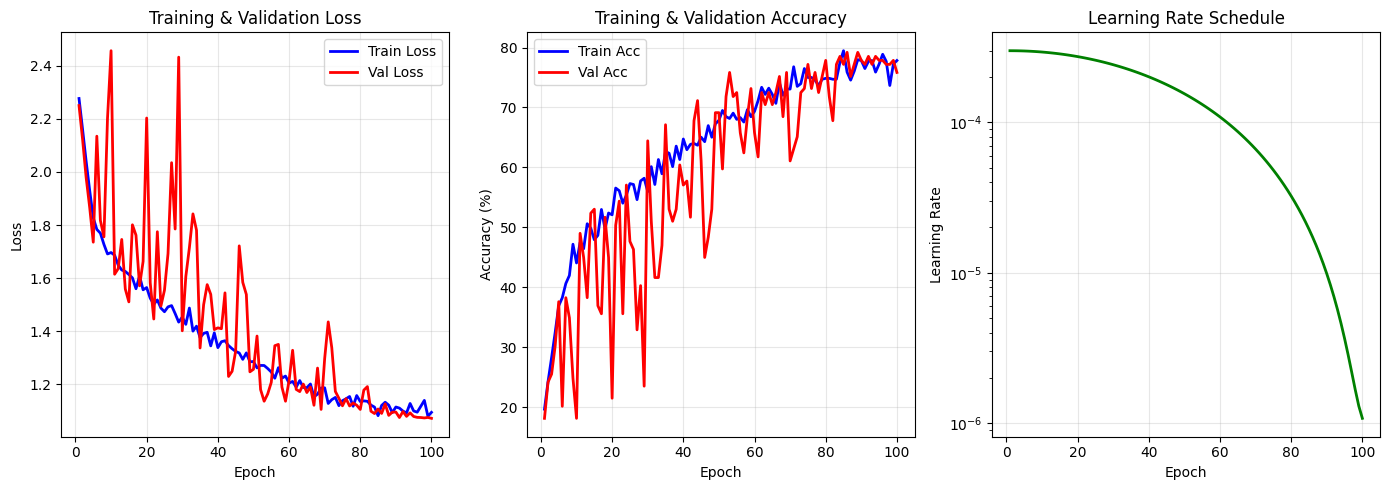


🧪 TEST DEĞERLENDİRMESİ

🔍 Model değerlendiriliyor...


Evaluating: 100%|██████████| 5/5 [00:00<00:00, 11.39it/s]



📊 SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

       blues     0.6250    0.6250    0.6250        16
   classical     0.8182    0.8182    0.8182        11
     country     0.5455    0.6316    0.5854        19
       disco     0.7647    0.6190    0.6842        21
      hiphop     0.6471    0.8462    0.7333        13
        jazz     0.8462    0.9167    0.8800        12
       metal     0.7143    0.8333    0.7692        12
         pop     0.7143    0.5882    0.6452        17
      reggae     0.6667    0.6667    0.6667        15
        rock     0.4167    0.3333    0.3704        15

    accuracy                         0.6689       151
   macro avg     0.6758    0.6878    0.6778       151
weighted avg     0.6686    0.6689    0.6645       151


📈 Özet Metrikler:
   Accuracy:  66.89%
   Precision: 66.86%
   Recall:    66.89%
   F1-Score:  66.45%
✅ Confusion matrix kaydedildi: ./checkpoints/cnn/cnn/confusion_matrix.png


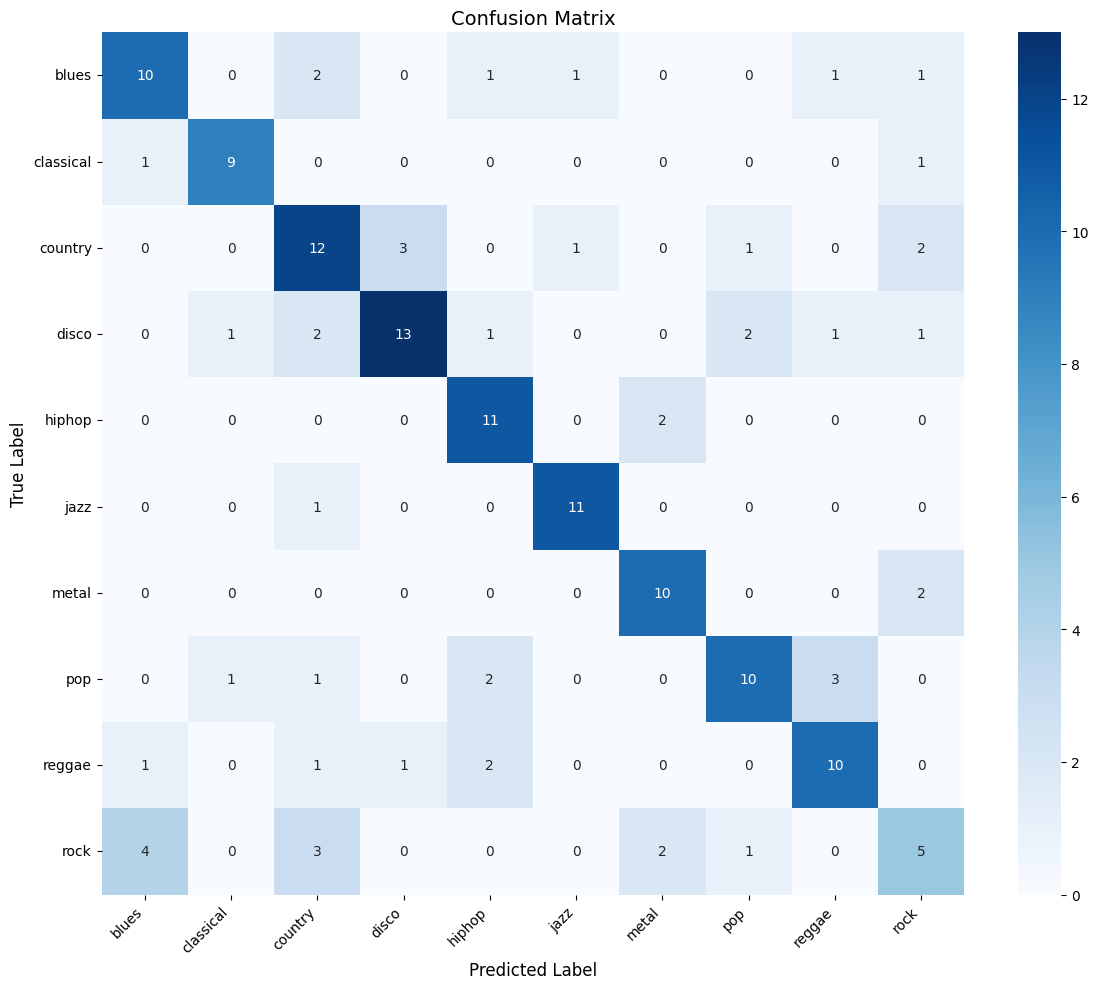

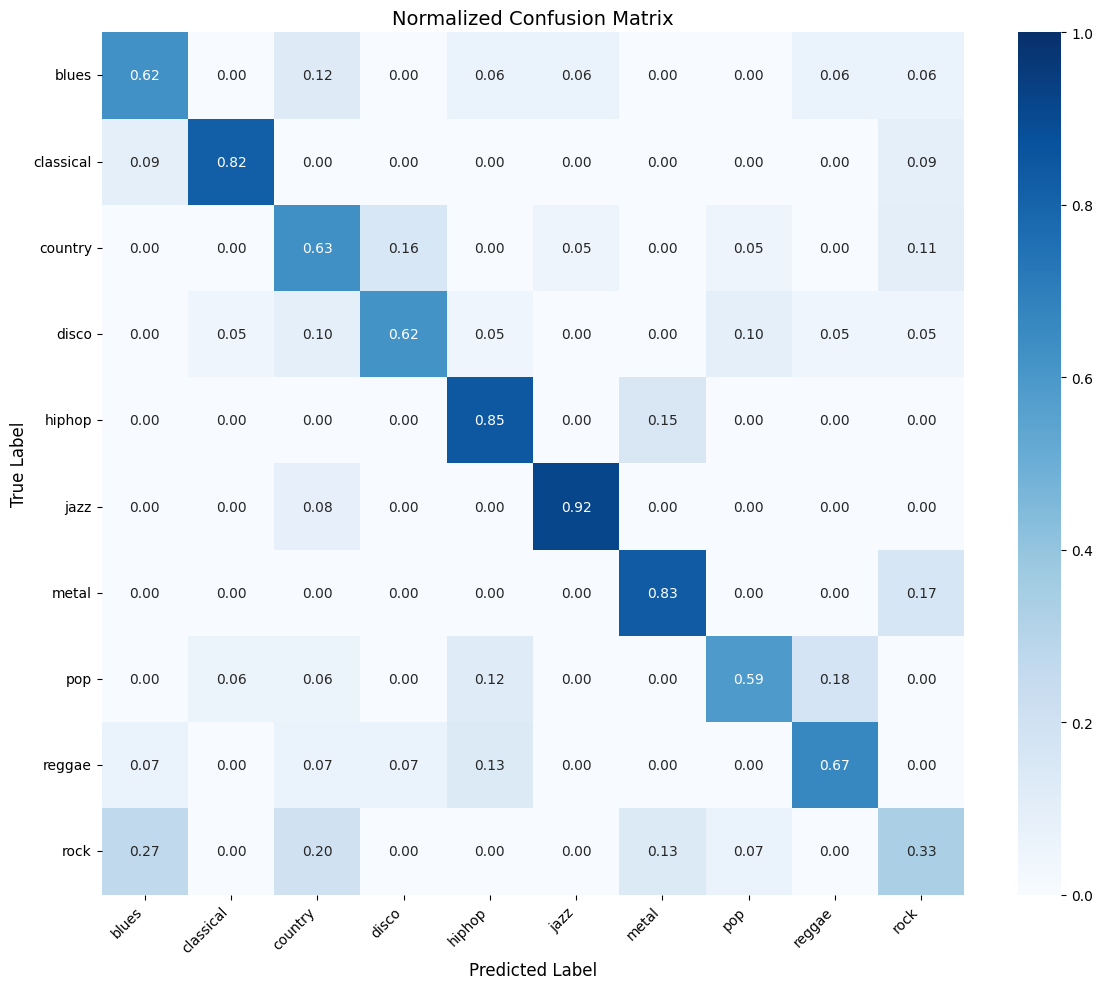

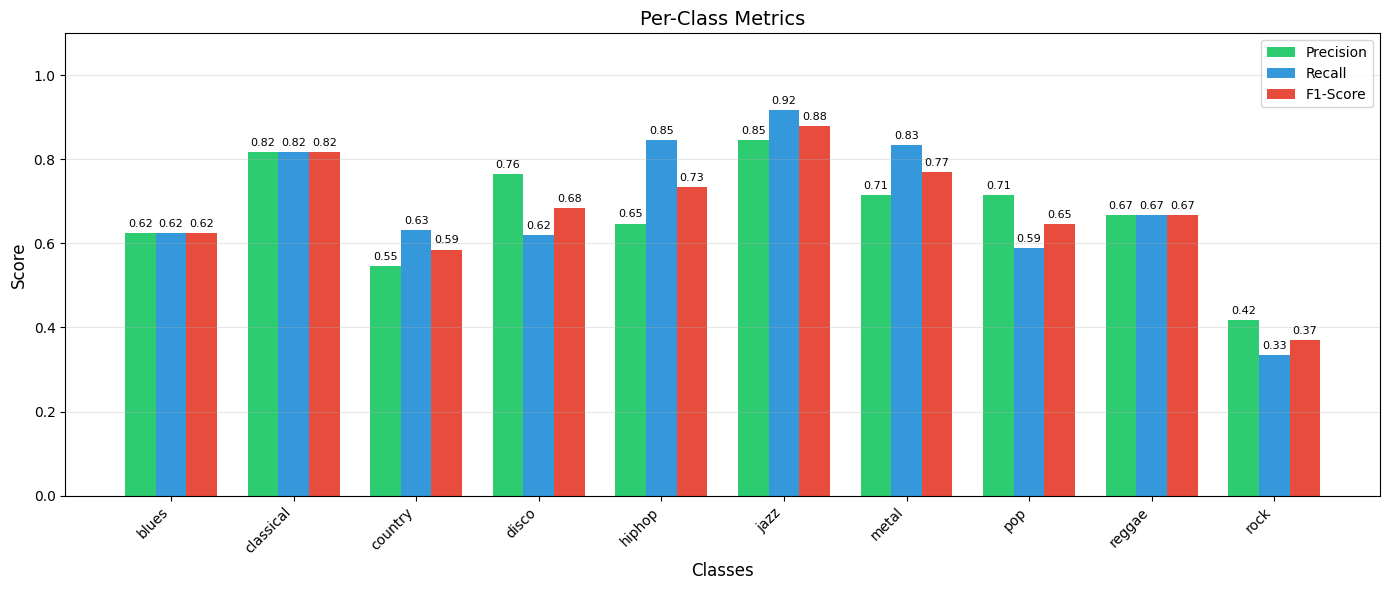


🔄 IMPROVED_CNN eğitiliyor...

############################################################
# Model: IMPROVED_CNN
############################################################
📊 Toplam 999 görüntü yüklendi.

📊 Dataset Split:
   Train: 699 (70%)
   Val:   149 (15%)
   Test:  151 (15%)

📋 improved_cnn Özeti
Toplam Parametre:    11,318,314
Eğitilebilir:        11,318,314
Dondurulmuş:         0


🚀 Eğitim Başlıyor
   Model: improved_cnn
   Device: mps
   Epochs: 100


Epoch 1/100
----------------------------------------


Train Loss: 2.2071 | Train Acc: 18.15%
Val Loss:   2.7057 | Val Acc:   13.42%
LR: 0.000300
✅ En iyi model kaydedildi!

Epoch 2/100
----------------------------------------


Train Loss: 2.0104 | Train Acc: 28.27%
Val Loss:   1.8203 | Val Acc:   35.57%
LR: 0.000300
✅ En iyi model kaydedildi!

Epoch 3/100
----------------------------------------


Train Loss: 1.8905 | Train Acc: 34.52%
Val Loss:   1.8991 | Val Acc:   28.86%
LR: 0.000300

Epoch 4/100
----------------------------------------


Train Loss: 1.8215 | Train Acc: 36.90%
Val Loss:   2.2864 | Val Acc:   19.46%
LR: 0.000299

Epoch 5/100
----------------------------------------


...

Train Loss: 0.7842 | Train Acc: 89.29%
Val Loss:   1.1789 | Val Acc:   74.50%
LR: 0.000045

Epoch 77/100
----------------------------------------


Train Loss: 0.7652 | Train Acc: 90.48%
Val Loss:   1.1855 | Val Acc:   77.85%
LR: 0.000042

Epoch 78/100
----------------------------------------


Train Loss: 0.7556 | Train Acc: 90.03%
Val Loss:   1.2315 | Val Acc:   73.15%
LR: 0.000038

Epoch 79/100
----------------------------------------


Train Loss: 0.7594 | Train Acc: 89.58%
Val Loss:   1.1937 | Val Acc:   73.15%
LR: 0.000035

Epoch 80/100
----------------------------------------


Train Loss: 0.7515 | Train Acc: 91.22%
Val Loss:   1.1834 | Val Acc:   75.84%
LR: 0.000032

⚠️ Early stopping! Epoch 80

🏁 Eğitim Tamamlandı!
   En İyi Val Loss: 1.1418 (Epoch 65)
   En İyi Val Acc:  76.51%
✅ Checkpoint yüklendi: best_model.pth
✅ Eğitim grafiği kaydedildi: ./checkpoints/improved_cnn/improved_cnn_history.png


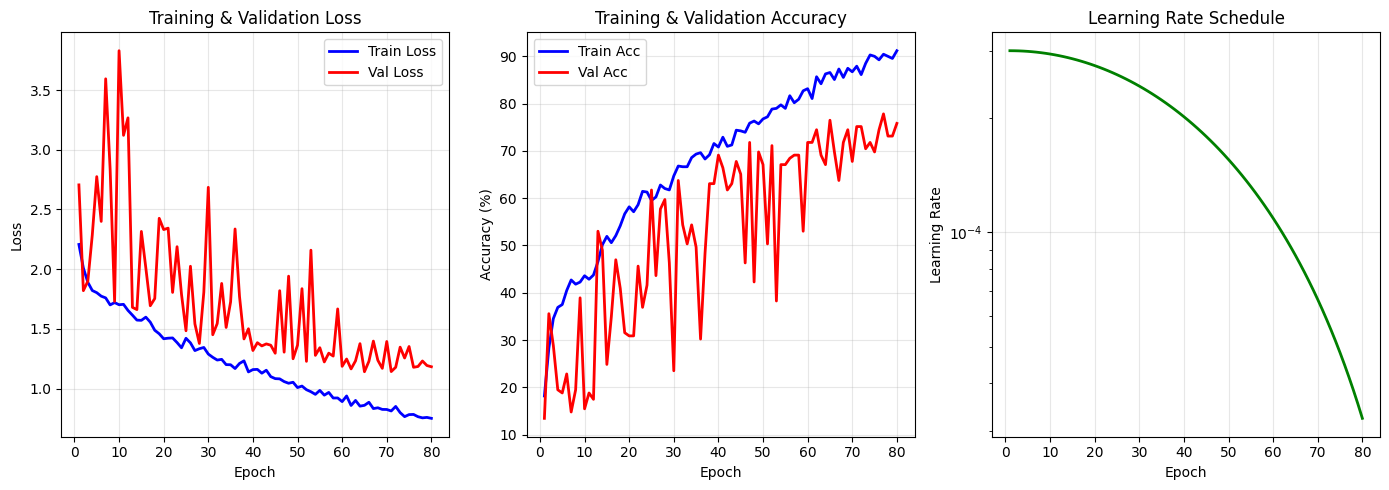


🧪 TEST DEĞERLENDİRMESİ

🔍 Model değerlendiriliyor...


Evaluating: 100%|██████████| 5/5 [00:00<00:00, 11.73it/s]



📊 SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

       blues     0.5652    0.8125    0.6667        16
   classical     0.7692    0.9091    0.8333        11
     country     0.6429    0.4737    0.5455        19
       disco     0.4615    0.5714    0.5106        21
      hiphop     1.0000    0.6154    0.7619        13
        jazz     0.6667    0.8333    0.7407        12
       metal     0.7692    0.8333    0.8000        12
         pop     0.5385    0.4118    0.4667        17
      reggae     0.6316    0.8000    0.7059        15
        rock     0.4286    0.2000    0.2727        15

    accuracy                         0.6225       151
   macro avg     0.6473    0.6461    0.6304       151
weighted avg     0.6271    0.6225    0.6088       151


📈 Özet Metrikler:
   Accuracy:  62.25%
   Precision: 62.71%
   Recall:    62.25%
   F1-Score:  60.88%
✅ Confusion matrix kaydedildi: ./checkpoints/improved_cnn/improved_cnn/confusion_matrix.png


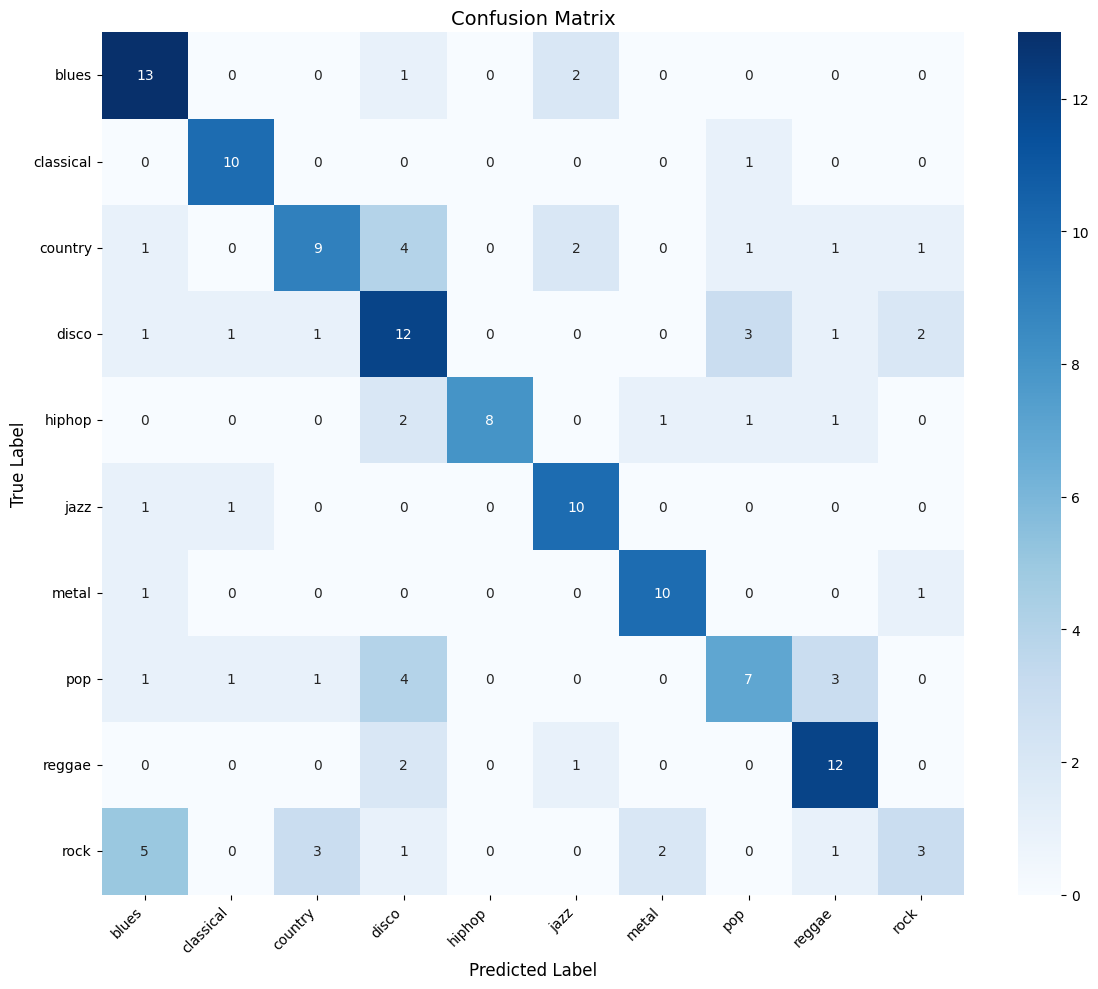

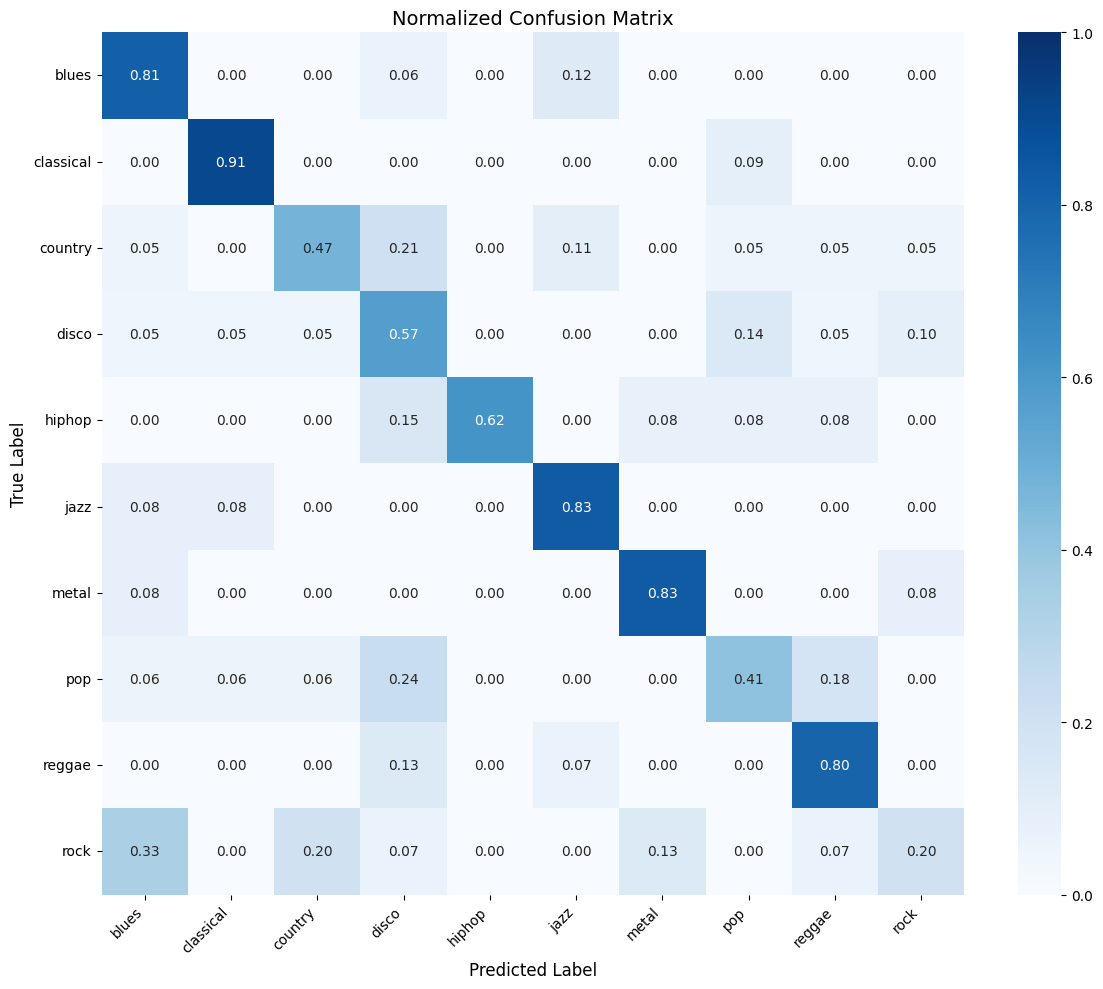

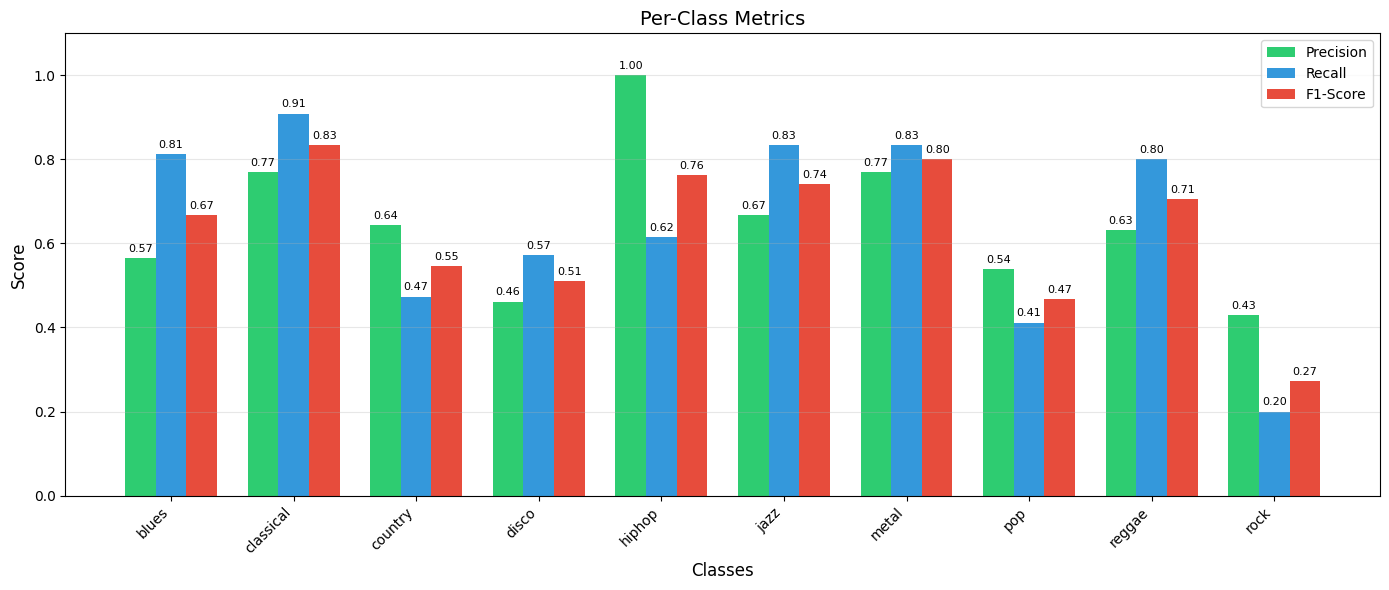


🔄 RESNET18 eğitiliyor...

############################################################
# Model: RESNET18
############################################################
📊 Toplam 999 görüntü yüklendi.

📊 Dataset Split:
   Train: 699 (70%)
   Val:   149 (15%)
   Test:  151 (15%)
✅ ResNet18 ImageNet ağırlıkları yüklendi

📋 resnet18 Özeti
Toplam Parametre:    11,310,410
Eğitilebilir:        11,310,410
Dondurulmuş:         0


🚀 Eğitim Başlıyor
   Model: resnet18
   Device: mps
   Epochs: 100


Epoch 1/100
----------------------------------------


Train Loss: 2.0436 | Train Acc: 29.17%
Val Loss:   1.7261 | Val Acc:   42.28%
LR: 0.000300
✅ En iyi model kaydedildi!

Epoch 2/100
----------------------------------------


Train Loss: 1.5558 | Train Acc: 53.87%
Val Loss:   1.2332 | Val Acc:   75.17%
LR: 0.000300
✅ En iyi model kaydedildi!

Epoch 3/100
----------------------------------------


Train Loss: 1.3481 | Train Acc: 62.95%
Val Loss:   1.3896 | Val Acc:   55.03%
LR: 0.000300

Epoch 4/100
----------------------------------------


Train Loss: 1.2320 | Train Acc: 68.01%
Val Loss:   1.5064 | Val Acc:   61.74%
LR: 0.000299

Epoch 5/100
----------------------------------------


...

Train Loss: 0.5509 | Train Acc: 98.51%
Val Loss:   0.9250 | Val Acc:   85.23%
LR: 0.000146

Epoch 53/100
----------------------------------------


Train Loss: 0.5400 | Train Acc: 99.40%
Val Loss:   0.9581 | Val Acc:   83.89%
LR: 0.000141

Epoch 54/100
----------------------------------------


Train Loss: 0.5489 | Train Acc: 99.26%
Val Loss:   0.8916 | Val Acc:   85.91%
LR: 0.000136

Epoch 55/100
----------------------------------------


Train Loss: 0.5331 | Train Acc: 100.00%
Val Loss:   0.8976 | Val Acc:   85.91%
LR: 0.000132

Epoch 56/100
----------------------------------------


Train Loss: 0.5376 | Train Acc: 99.26%
Val Loss:   0.9209 | Val Acc:   83.89%
LR: 0.000127

⚠️ Early stopping! Epoch 56

🏁 Eğitim Tamamlandı!
   En İyi Val Loss: 0.8671 (Epoch 41)
   En İyi Val Acc:  86.58%
✅ Checkpoint yüklendi: best_model.pth
✅ Eğitim grafiği kaydedildi: ./checkpoints/resnet18/resnet18_history.png


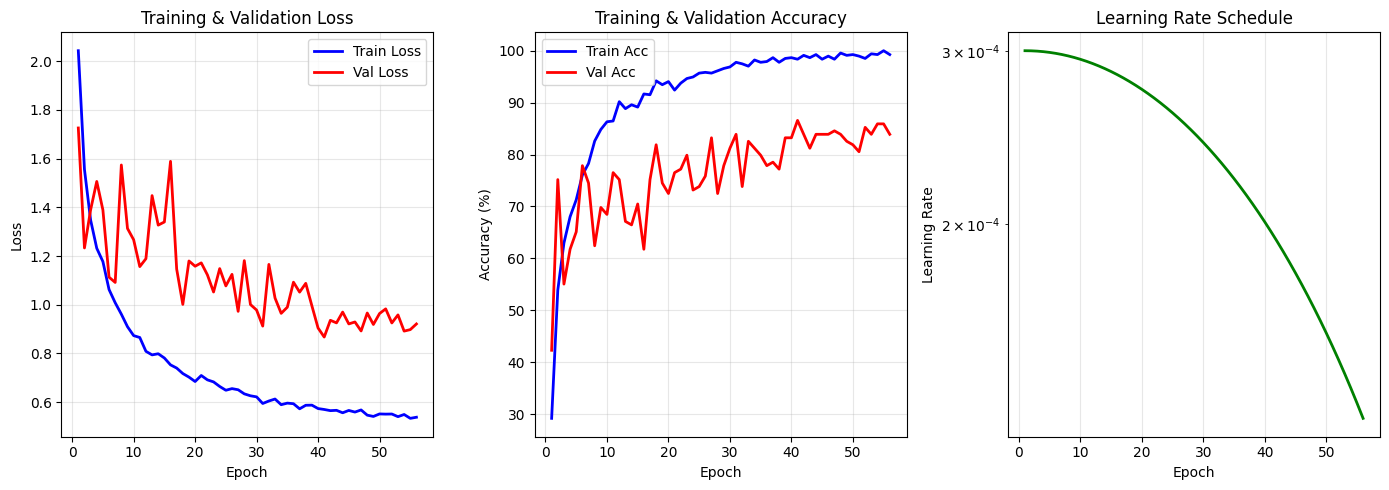


🧪 TEST DEĞERLENDİRMESİ

🔍 Model değerlendiriliyor...


Evaluating: 100%|██████████| 5/5 [00:00<00:00, 13.25it/s]



📊 SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

       blues     0.6875    0.6875    0.6875        16
   classical     1.0000    0.9091    0.9524        11
     country     0.5000    0.5789    0.5366        19
       disco     0.7647    0.6190    0.6842        21
      hiphop     0.7692    0.7692    0.7692        13
        jazz     0.8462    0.9167    0.8800        12
       metal     0.8571    1.0000    0.9231        12
         pop     0.6522    0.8824    0.7500        17
      reggae     0.8182    0.6000    0.6923        15
        rock     0.5000    0.4000    0.4444        15

    accuracy                         0.7152       151
   macro avg     0.7395    0.7363    0.7320       151
weighted avg     0.7209    0.7152    0.7118       151


📈 Özet Metrikler:
   Accuracy:  71.52%
   Precision: 72.09%
   Recall:    71.52%
   F1-Score:  71.18%
✅ Confusion matrix kaydedildi: ./checkpoints/resnet18/resnet18/confusion_matrix.png


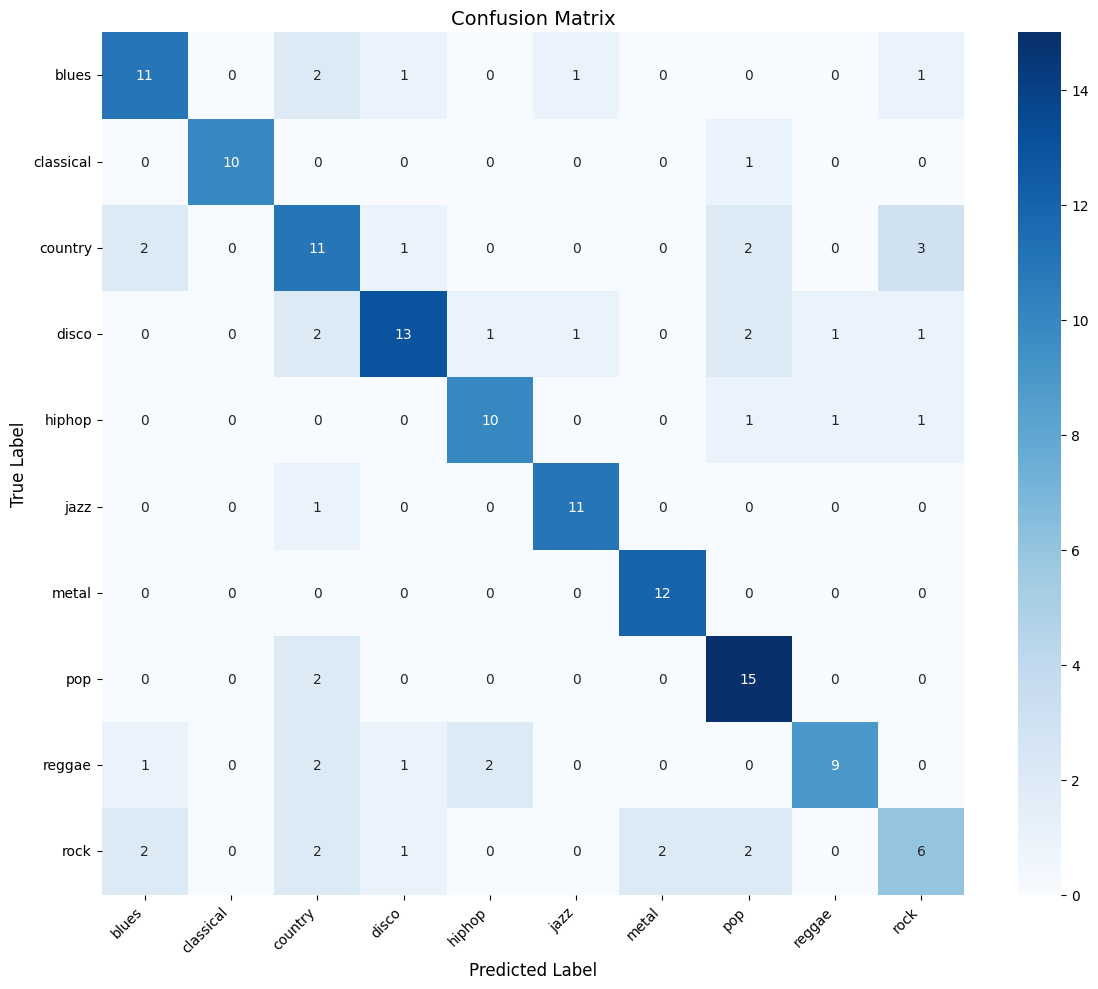

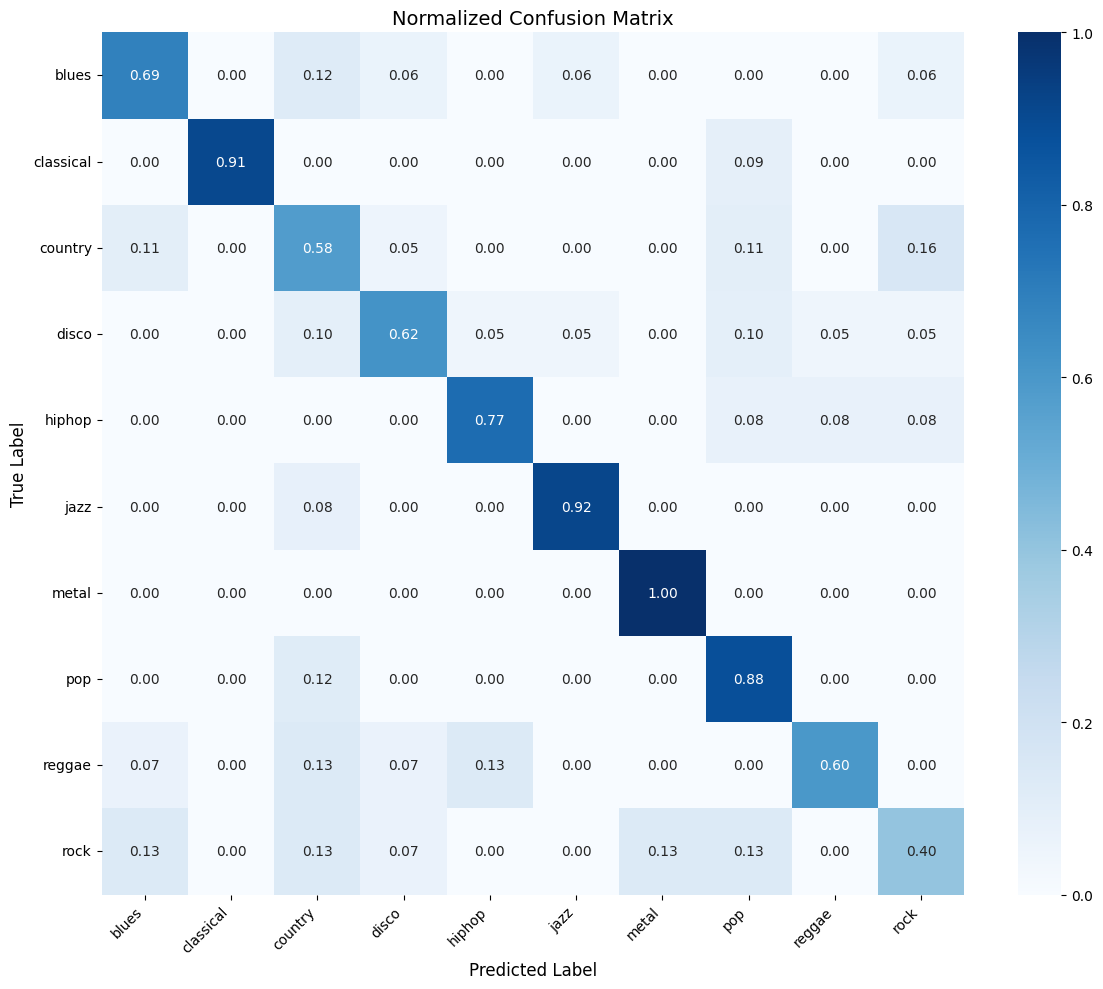

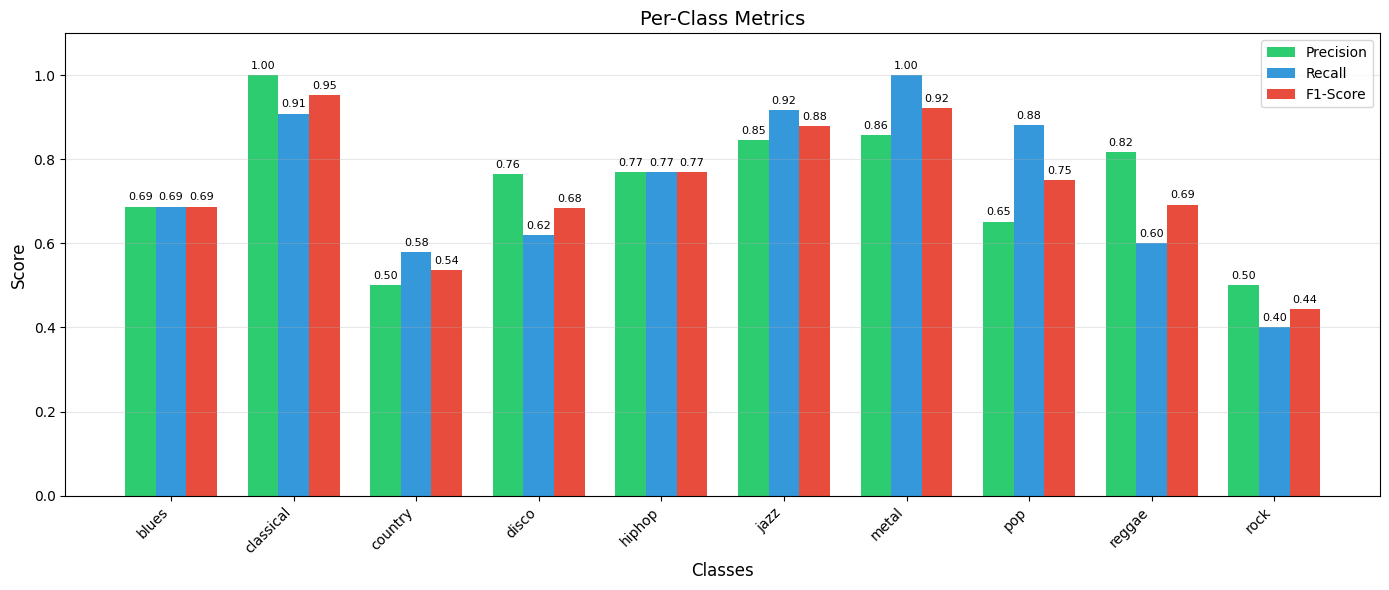


🔄 EFFICIENTNET eğitiliyor...

############################################################
# Model: EFFICIENTNET
############################################################
📊 Toplam 999 görüntü yüklendi.

📊 Dataset Split:
   Train: 699 (70%)
   Val:   149 (15%)
   Test:  151 (15%)
✅ EfficientNet-B0 ImageNet ağırlıkları yüklendi

📋 efficientnet Özeti
Toplam Parametre:    4,797,318
Eğitilebilir:        4,797,318
Dondurulmuş:         0


🚀 Eğitim Başlıyor
   Model: efficientnet
   Device: mps
   Epochs: 100


Epoch 1/100
----------------------------------------


Train Loss: 2.1636 | Train Acc: 25.74%
Val Loss:   1.9180 | Val Acc:   34.23%
LR: 0.000300
✅ En iyi model kaydedildi!

Epoch 2/100
----------------------------------------


Train Loss: 1.7470 | Train Acc: 43.75%
Val Loss:   1.7103 | Val Acc:   47.65%
LR: 0.000300
✅ En iyi model kaydedildi!

Epoch 3/100
----------------------------------------


Train Loss: 1.5173 | Train Acc: 55.06%
Val Loss:   1.2975 | Val Acc:   61.07%
LR: 0.000300
✅ En iyi model kaydedildi!

Epoch 4/100
----------------------------------------


Train Loss: 1.3193 | Train Acc: 63.69%
Val Loss:   1.2638 | Val Acc:   66.44%
LR: 0.000299
✅ En iyi model kaydedildi!

Epoch 5/100
----------------------------------------


...

Train Loss: 0.5263 | Train Acc: 99.26%
Val Loss:   0.9382 | Val Acc:   85.23%
LR: 0.000127

Epoch 57/100
----------------------------------------


Train Loss: 0.5220 | Train Acc: 99.26%
Val Loss:   0.9111 | Val Acc:   85.91%
LR: 0.000122

Epoch 58/100
----------------------------------------


Train Loss: 0.5346 | Train Acc: 98.96%
Val Loss:   0.8979 | Val Acc:   87.25%
LR: 0.000118

Epoch 59/100
----------------------------------------


Train Loss: 0.5232 | Train Acc: 99.11%
Val Loss:   0.8993 | Val Acc:   87.25%
LR: 0.000113

Epoch 60/100
----------------------------------------


Train Loss: 0.5314 | Train Acc: 98.36%
Val Loss:   0.8967 | Val Acc:   87.25%
LR: 0.000109

⚠️ Early stopping! Epoch 60

🏁 Eğitim Tamamlandı!
   En İyi Val Loss: 0.8911 (Epoch 45)
   En İyi Val Acc:  84.56%
✅ Checkpoint yüklendi: best_model.pth
✅ Eğitim grafiği kaydedildi: ./checkpoints/efficientnet/efficientnet_history.png


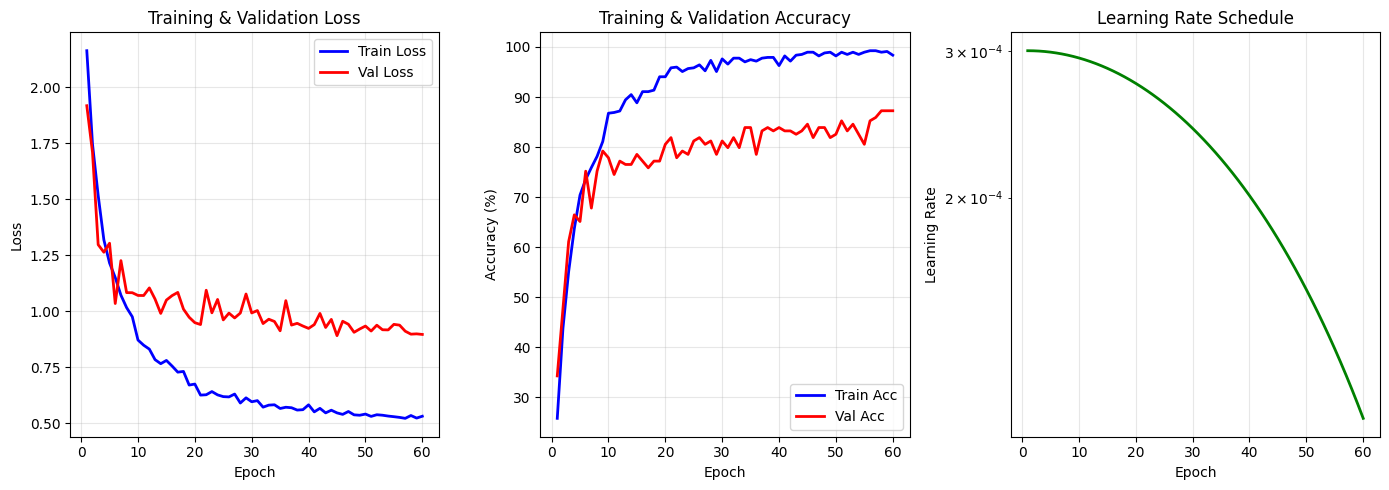


🧪 TEST DEĞERLENDİRMESİ

🔍 Model değerlendiriliyor...


Evaluating: 100%|██████████| 5/5 [00:00<00:00,  6.94it/s]


📊 SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

       blues     0.8235    0.8750    0.8485        16
   classical     0.9091    0.9091    0.9091        11
     country     0.7059    0.6316    0.6667        19
       disco     0.6087    0.6667    0.6364        21
      hiphop     0.8182    0.6923    0.7500        13
        jazz     0.7059    1.0000    0.8276        12
       metal     0.9167    0.9167    0.9167        12
         pop     0.9091    0.5882    0.7143        17
      reggae     0.6316    0.8000    0.7059        15
        rock     0.6923    0.6000    0.6429        15

    accuracy                         0.7483       151
   macro avg     0.7721    0.7680    0.7618       151
weighted avg     0.7602    0.7483    0.7461       151


📈 Özet Metrikler:
   Accuracy:  74.83%
   Precision: 76.02%
   Recall:    74.83%
   F1-Score:  74.61%
✅ Confusion matrix kaydedildi: ./checkpoints/efficientnet/efficientnet/confusion_matrix.png


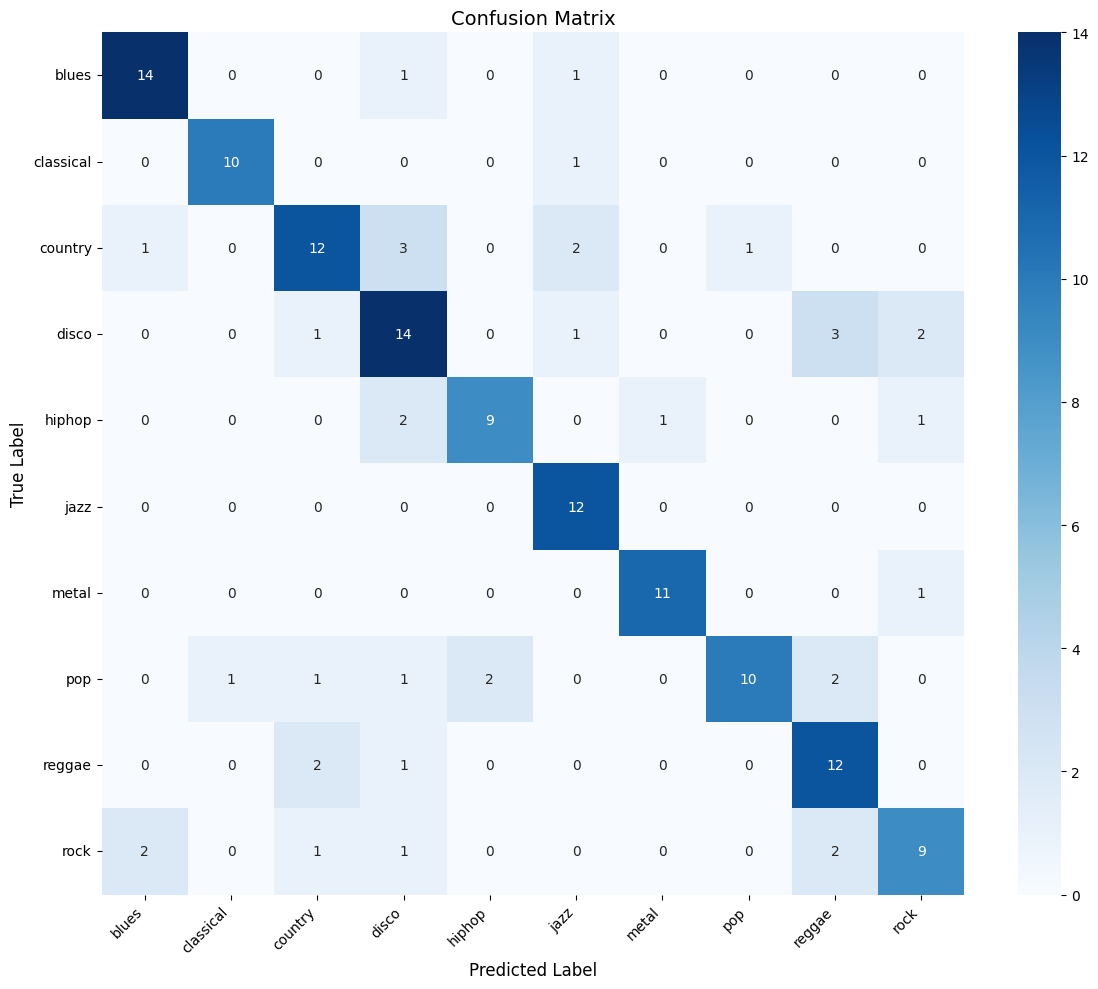

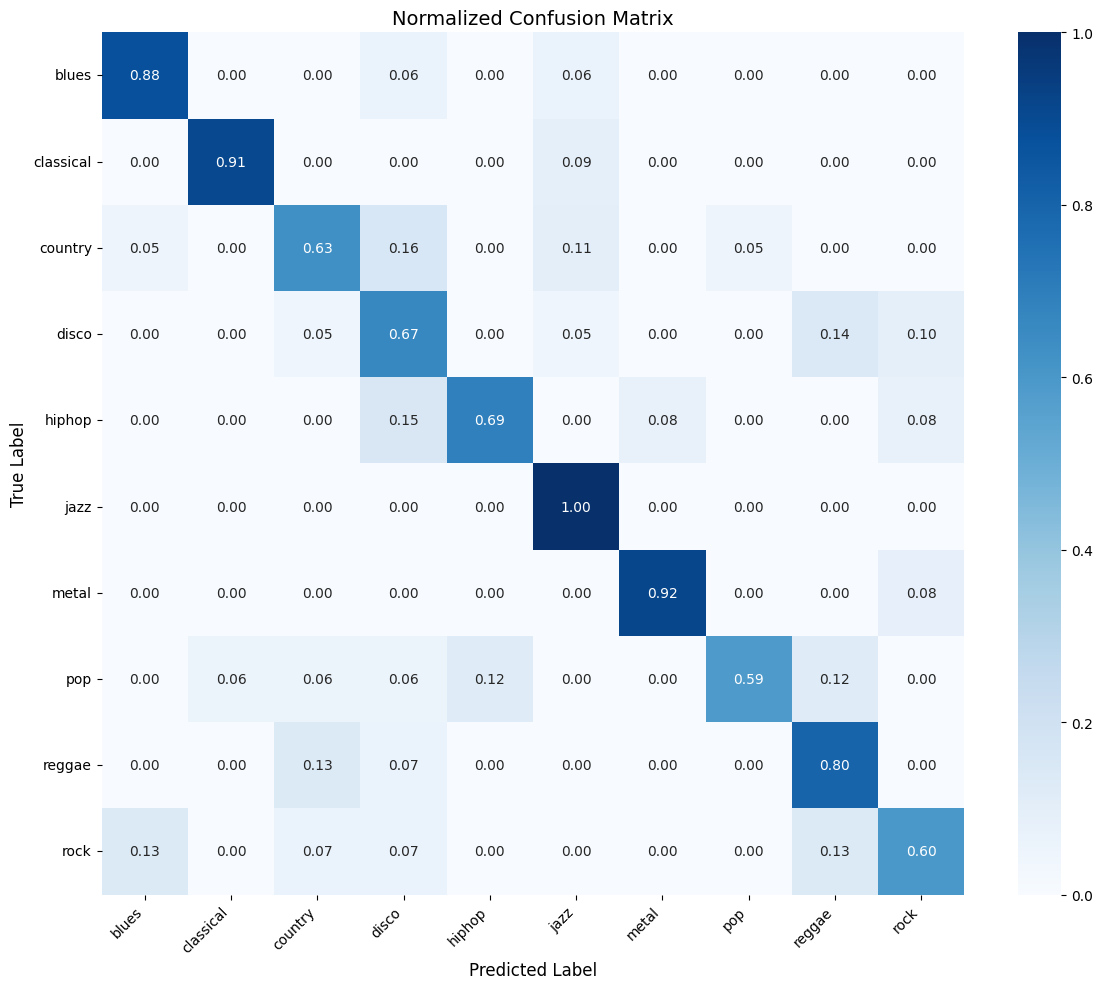

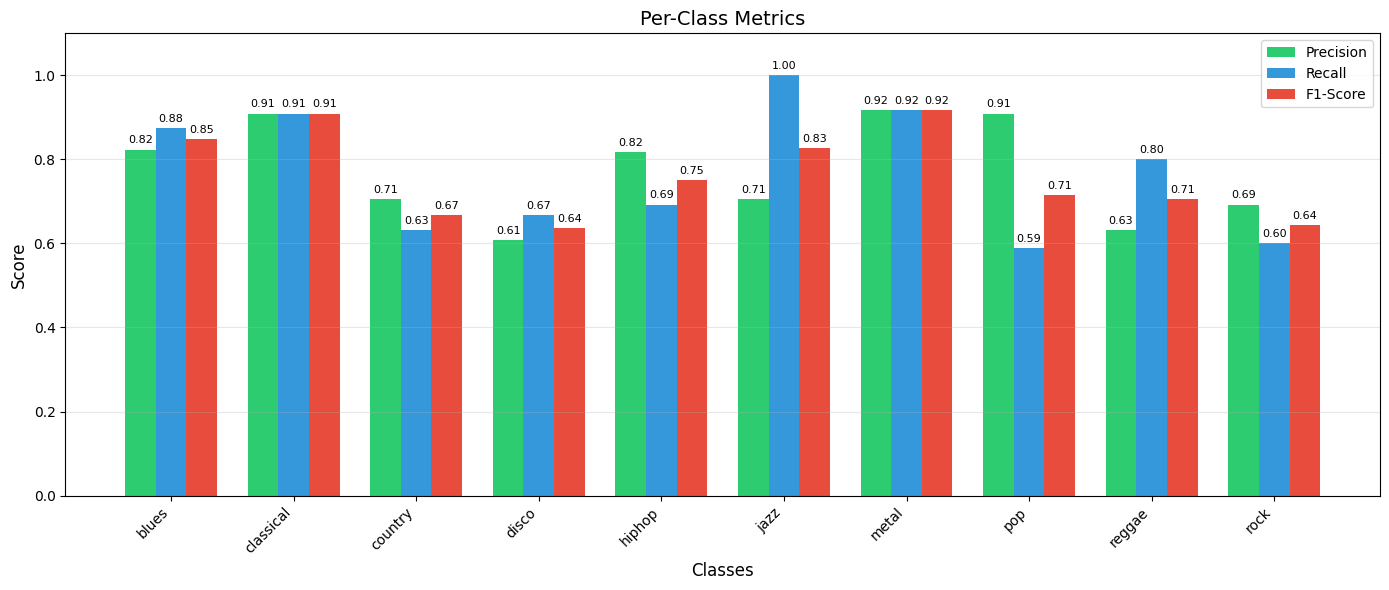


🔄 ENHANCED_CNN eğitiliyor...

############################################################
# Model: ENHANCED_CNN
############################################################
📊 Toplam 999 görüntü yüklendi.

📊 Dataset Split:
   Train: 699 (70%)
   Val:   149 (15%)
   Test:  151 (15%)

📋 enhanced_cnn Özeti
Toplam Parametre:    11,793,482
Eğitilebilir:        11,793,482
Dondurulmuş:         0


🚀 Eğitim Başlıyor
   Model: enhanced_cnn
   Device: mps
   Epochs: 100


Epoch 1/100
----------------------------------------


Train Loss: 2.3930 | Train Acc: 14.58%
Val Loss:   2.2202 | Val Acc:   16.11%
LR: 0.000300
✅ En iyi model kaydedildi!

Epoch 2/100
----------------------------------------


Train Loss: 2.1005 | Train Acc: 25.00%
Val Loss:   1.9810 | Val Acc:   28.19%
LR: 0.000300
✅ En iyi model kaydedildi!

Epoch 3/100
----------------------------------------


Train Loss: 1.9350 | Train Acc: 31.70%
Val Loss:   2.0580 | Val Acc:   26.17%
LR: 0.000300

Epoch 4/100
----------------------------------------


Train Loss: 1.8671 | Train Acc: 34.82%
Val Loss:   2.4053 | Val Acc:   22.82%
LR: 0.000299

Epoch 5/100
----------------------------------------


...

Train Loss: 1.0598 | Train Acc: 76.19%
Val Loss:   1.5338 | Val Acc:   61.07%
LR: 0.000201

Epoch 41/100
----------------------------------------


Train Loss: 1.1019 | Train Acc: 72.77%
Val Loss:   2.1997 | Val Acc:   38.26%
LR: 0.000197

Epoch 42/100
----------------------------------------


Train Loss: 1.0814 | Train Acc: 76.04%
Val Loss:   2.0006 | Val Acc:   40.27%
LR: 0.000192

Epoch 43/100
----------------------------------------


Train Loss: 1.0865 | Train Acc: 73.96%
Val Loss:   1.6255 | Val Acc:   49.66%
LR: 0.000188

Epoch 44/100
----------------------------------------


Train Loss: 1.0545 | Train Acc: 77.53%
Val Loss:   1.4170 | Val Acc:   66.44%
LR: 0.000183

⚠️ Early stopping! Epoch 44

🏁 Eğitim Tamamlandı!
   En İyi Val Loss: 1.2617 (Epoch 29)
   En İyi Val Acc:  65.77%
✅ Checkpoint yüklendi: best_model.pth
✅ Eğitim grafiği kaydedildi: ./checkpoints/enhanced_cnn/enhanced_cnn_history.png


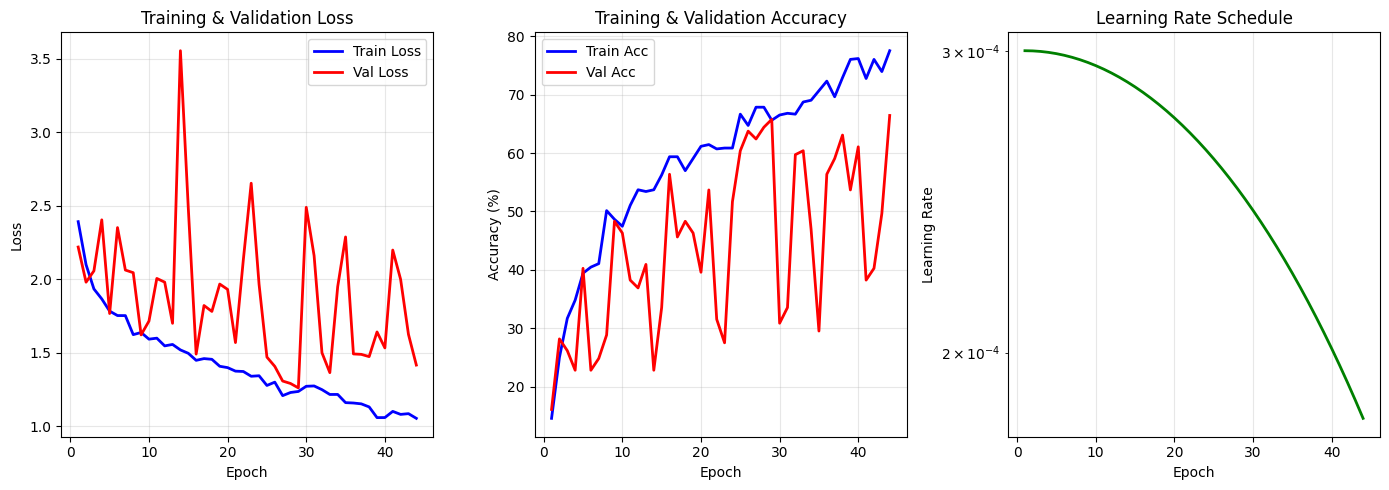


🧪 TEST DEĞERLENDİRMESİ

🔍 Model değerlendiriliyor...


Evaluating: 100%|██████████| 5/5 [00:00<00:00, 11.51it/s]



📊 SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

       blues     0.5000    0.5625    0.5294        16
   classical     0.7273    0.7273    0.7273        11
     country     0.4211    0.4211    0.4211        19
       disco     0.6000    0.2857    0.3871        21
      hiphop     0.5714    0.9231    0.7059        13
        jazz     0.7273    0.6667    0.6957        12
       metal     0.8182    0.7500    0.7826        12
         pop     0.4444    0.7059    0.5455        17
      reggae     0.6000    0.2000    0.3000        15
        rock     0.2778    0.3333    0.3030        15

    accuracy                         0.5298       151
   macro avg     0.5687    0.5575    0.5397       151
weighted avg     0.5516    0.5298    0.5155       151


📈 Özet Metrikler:
   Accuracy:  52.98%
   Precision: 55.16%
   Recall:    52.98%
   F1-Score:  51.55%
✅ Confusion matrix kaydedildi: ./checkpoints/enhanced_cnn/enhanced_cnn/confusion_matrix.png


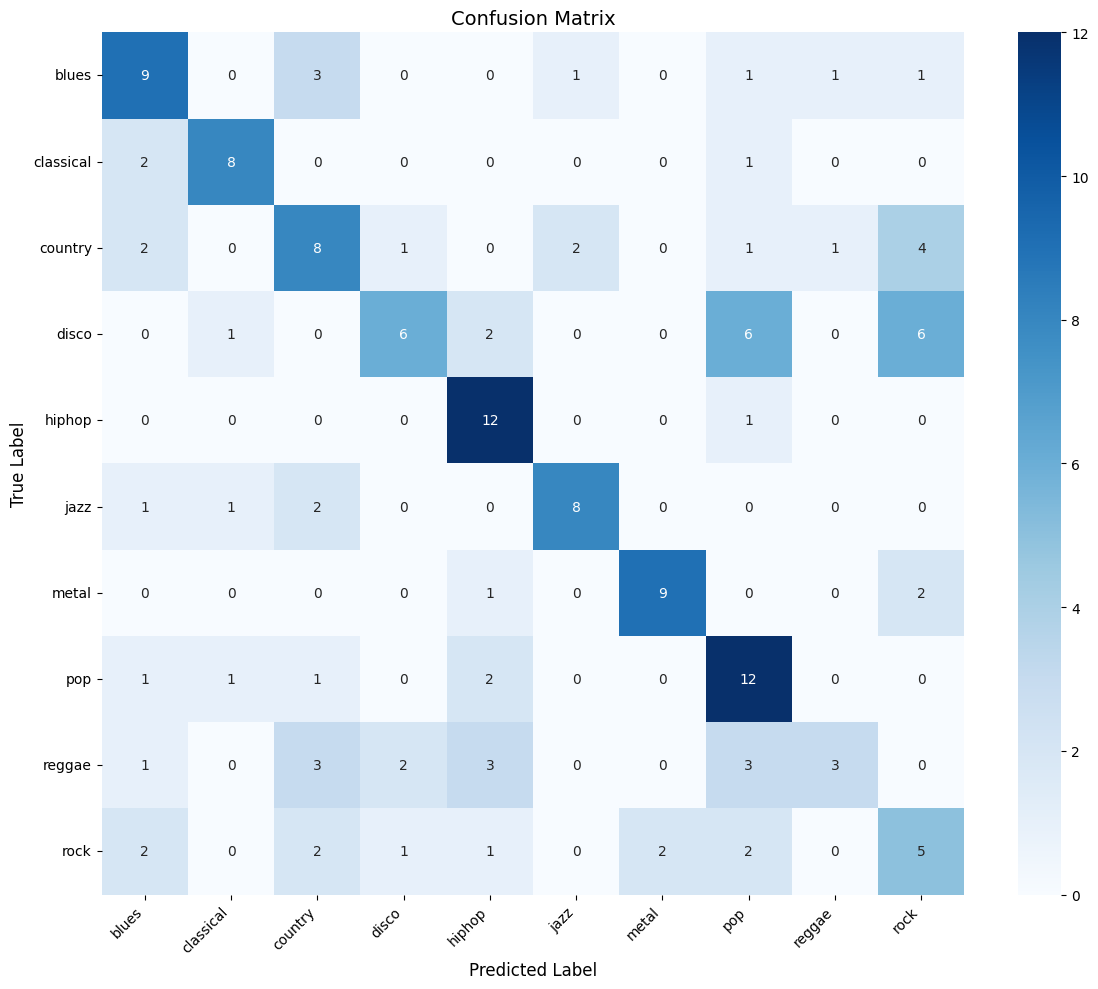

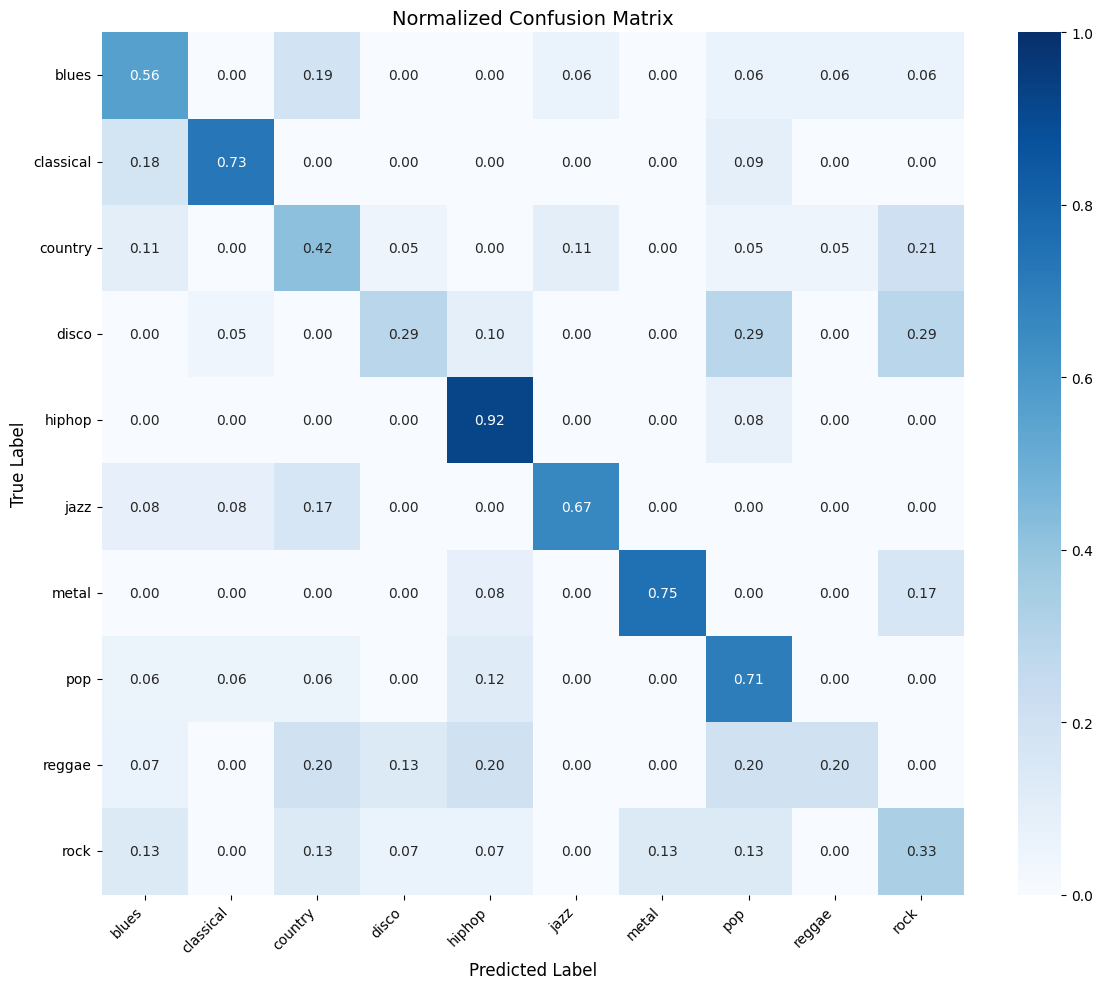

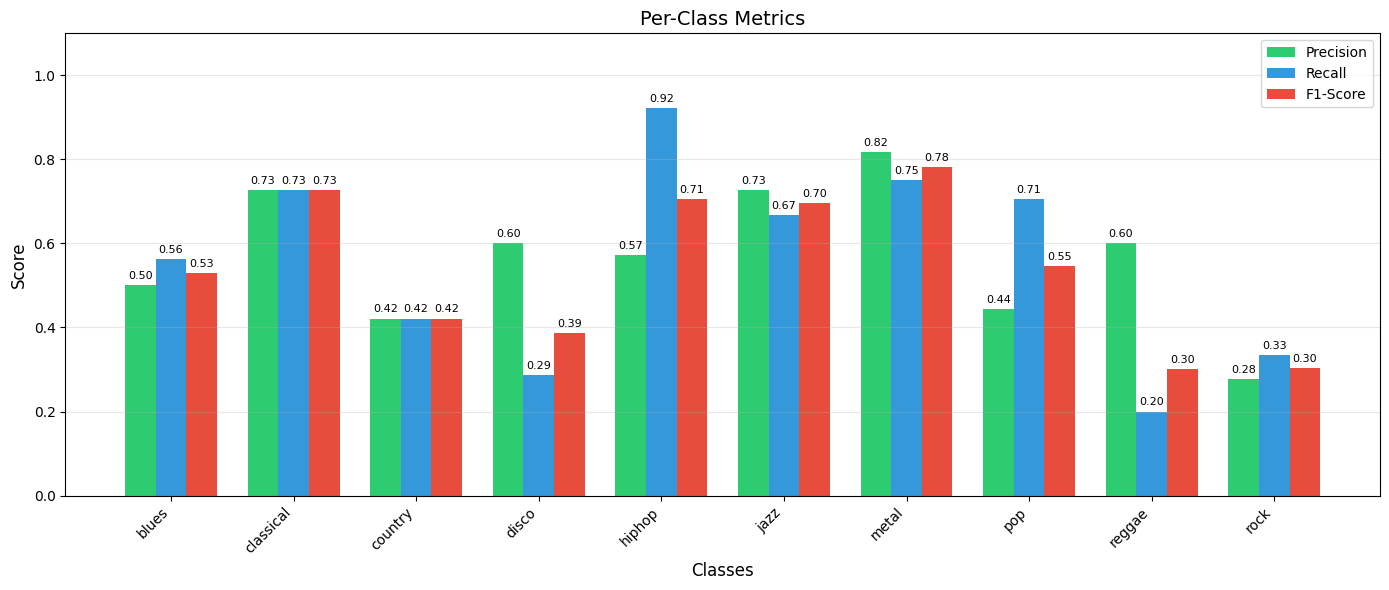


📊 MODEL KARŞILAŞTIRMASI
✅ Karşılaştırma grafiği kaydedildi: ./results/model_comparison.png


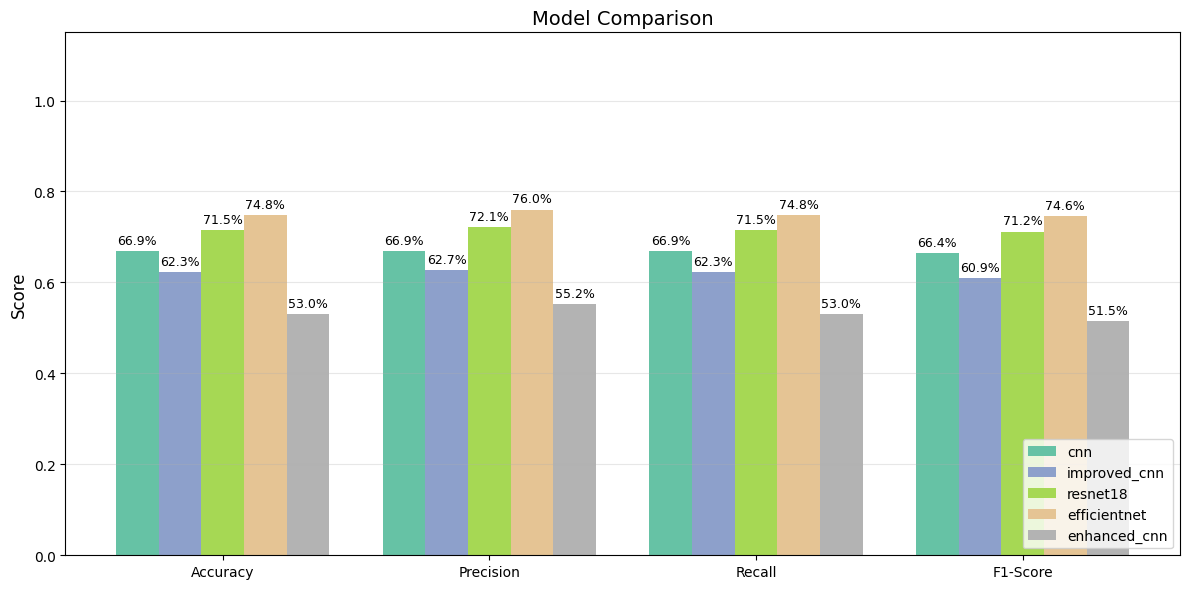


🏆 En İyi Model: EFFICIENTNET
   Accuracy: 74.83%

✅ İşlem tamamlandı!


In [18]:
def train_single_model(config: Config):
    """Tek bir modeli eğit ve değerlendir"""

    print(f"\n{'#'*60}")
    print(f"# Model: {config.model_name.upper()}")
    print(f"{'#'*60}")

    # DataLoader'ları oluştur
    dataloaders = create_dataloaders(config)

    # Model oluştur
    model = get_model(
        model_name=config.model_name,
        num_classes=config.num_classes,
        pretrained=config.pretrained,
        dropout_rate=config.dropout_rate
    )

    # Model özeti
    print_model_summary(model, config.model_name)

    # Eğit
    trained_model, history = train_model(model, dataloaders, config)

    # Eğitim grafiği
    plot_training_history(
        history,
        save_path=os.path.join(config.save_dir, f'{config.model_name}_history.png')
    )

    # Test değerlendirmesi
    print("\n" + "="*60)
    print("🧪 TEST DEĞERLENDİRMESİ")
    print("="*60)

    metrics = evaluate_model(
        trained_model,
        dataloaders['test'],
        config,
        plot_results=True,
        save_plots=True,
        save_dir=os.path.join(config.save_dir, config.model_name)
    )

    return trained_model, history, metrics


def compare_all_models(config: Config):
    """Tüm modelleri eğit ve karşılaştır"""
    model_names = ['cnn','improved_cnn','resnet18', 'efficientnet','enhanced_cnn']
    all_results = {}

    for model_name in model_names:
        print(f"\n{'='*60}")
        print(f"🔄 {model_name.upper()} eğitiliyor...")
        print(f"{'='*60}")

        # Config'i güncelle
        config.model_name = model_name
        config.save_dir = f'./checkpoints/{model_name}'

        # Eğit ve değerlendir
        _, _, metrics = train_single_model(config)

        all_results[model_name] = metrics

    # Sonuçları karşılaştır
    print("\n" + "="*60)
    print("📊 MODEL KARŞILAŞTIRMASI")
    print("="*60)

    compare_models(
        all_results,
        save_path='./results/model_comparison.png'
    )

    # En iyi modeli bul
    best_model = max(all_results.keys(), key=lambda x: all_results[x]['accuracy'])
    print(f"\n🏆 En İyi Model: {best_model.upper()}")
    print(f"   Accuracy: {all_results[best_model]['accuracy']*100:.2f}%")

    return all_results


def main():
    config = Config()
    config.compare_all=True
    # Seed ayarla
    set_seed(config.seed)

    # Kayıt dizini oluştur
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    config.save_dir = f'./checkpoints/{config.model_name}_{timestamp}'
    os.makedirs(config.save_dir, exist_ok=True)

    if config.compare_all:
        # Tüm modelleri karşılaştır
        results = compare_all_models(config)
    else:
        # Tek model eğit
        model, history, metrics = train_single_model(config)

    print("\n✅ İşlem tamamlandı!")


if __name__ == '__main__':
    main()